# Signal-Level Explainability of WDCNN for Bearing Fault Diagnosis via SHAP DeepExplainer

**Author:** Toto Suharto

## Abstract

Deep learning models for bearing fault diagnosis achieve near-perfect accuracy but lack interpretability at the signal level. We address this by applying SHAP DeepExplainer directly to the raw 2,048-point vibration input of WDCNN — producing, for the first time, per-sample-point attribution maps that reveal *which signal regions* the model uses for each fault decision. Building on these attributions, we propose **Fault Signature Maps (FSM)**: a formalized class-averaged SHAP fingerprint with three variants (signed, absolute, variance) and quantitative metrics (discriminability, severity monotonicity, split-half stability). On the CWRU dataset (Load 1, 10 classes, temporal split), WDCNN achieves strong test accuracy with validation-based early stopping. Key findings: (1) FSMs are highly stable (split-half cosine similarity = 0.940); (2) Ball fault FSM shows the highest severity monotonicity (17.6% of positions), IR/OR lower (13.8%, 8.6%) — severity is not encoded as a uniform increase; (3) in the ablation study (Section 9), removing BatchNorm (Variant C, implemented as class WDCNN_NoBN) increases FSM discriminability by ~2.3× at a 3.6% accuracy cost, revealing an accuracy–explainability trade-off. The ablation in Section 9 implements and trains Variants A (full), B (narrow kernel), and C (No BatchNorm).

**Keywords:** WDCNN, SHAP DeepExplainer, Signal-Level XAI, Bearing Fault Diagnosis, CWRU, Fault Signature Maps

## 1. Introduction and Related Work

**Context.** WDCNN (Zhang et al., 2017) is the most cited 1D-CNN for bearing fault diagnosis, achieving >99% on CWRU by processing raw vibration signals with a wide first kernel (64, stride 16). Yet no existing study explains *where in the signal* the model focuses. Prior SHAP work in fault diagnosis (Santos et al. 2024; Wang 2025; Farooq 2025) targets hand-crafted features (9–15 statistical features), not raw waveforms. Santos et al. (2024) apply SHAP for efficient feature selection in rolling bearing fault diagnosis using SVM on CWRU with time-domain statistical features. Grad-CAM and TCAV (Meisner 2023) operate at feature-map resolution, orders of magnitude coarser than the signal itself.

**Gap.** Signal-level SHAP for deep bearing models is unexplored. No per-sample-point attribution maps exist for WDCNN.

**Contributions.**

1. **Signal-level SHAP** — first DeepExplainer analysis on WDCNN producing 2,048 SHAP values per sample per class on raw vibration input.
2. **Fault Signature Maps (FSM)** — formalized class-averaged SHAP fingerprints (signed, absolute, variance variants) with quantitative metrics: discriminability index, severity monotonicity, and split-half stability.
3. **Architecture ablation** — three WDCNN variants (full, narrow kernel, no BatchNorm) confirm wide kernel and BatchNorm as critical components; No-BN reveals an accuracy–explainability trade-off.

## 2. Methodology

**Step 1 — Dataset.** CWRU bearing dataset, 48 kHz drive-end accelerometer, 10 classes (Normal + 3 fault types × 3 severities: Ball, Inner Race, Outer Race at 0.007″/0.014″/0.021″).

**Step 2 — Segmentation & Normalisation.** 2,048-point non-overlapping segments, 230 per class (2,300 total). Per-feature `StandardScaler` fitted on training data only, applied to val/test via shared `cwru_data_utils` module.

**Step 3 — Temporal Train/Val/Test Split.** 1,240 train / 310 val / 750 test. Temporal ordering avoids same-recording leakage across splits.

**Step 4 — WDCNN Training.** Zhang et al. (2017): Conv1d(1→16, kernel 64, stride 16) → 4 × Conv1d(3, stride 1) with BatchNorm + ReLU + MaxPool → FC(10). Total: **60,710 parameters**. Trained with Adam (lr=1e-3, weight decay=1e-4), early stopping (patience 15, best validation loss checkpoint saved).

**Step 5 — Model Evaluation.** Test accuracy, per-class F1, and confusion matrix on the held-out 750-sample temporal test set.

**Step 6 — SHAP DeepExplainer.** Stratified background (300 samples, 30/class) and test samples (500 samples, 50/class). Helper `_get_shap_for_class()` normalises list or 4D tensor SHAP output to `(n_samples, 2048)` per class.

**Step 7 — SHAP Attribution Maps.** Output: 10 arrays each of shape `(test × 2048)` — per-sample-point attribution per class. Visualised as global importance bar charts, per-class profiles, and raw-signal overlays.

**Step 8 — Fault Signature Maps (FSM).** Three formal definitions for class *c* and time index *t*, over samples *S_c* correctly classified as *c*:
- **Signed FSM:** FSM_signed(c,t) = (1/|S_c|) Σ φ_{c,i}(t) — preserves direction; cancellation possible.
- **Absolute FSM:** FSM_abs(c,t) = (1/|S_c|) Σ |φ_{c,i}(t)| — magnitude-preserving, used as **primary**.
- **Variance FSM:** FSM_var(c,t) = Var_{i∈S_c}[φ_{c,i}(t)] — captures attribution variability.

**Step 9 — FSM Quantitative Metrics.** Three metrics assess FSM quality:
- *Discriminability Index*: intra-class cosine similarity / inter-class similarity (higher = more discriminative).
- *Severity Monotonicity*: fraction of 2048 positions where FSM increases with fault severity (0.007″→0.021″).
- *Split-Half Stability Coefficient*: cosine similarity of FSMs computed on two independent halves of each class.

**Step 10 — Ablation Study.** Three WDCNN variants trained for 50 epochs to isolate component contributions:
- Variant A — Full WDCNN (baseline).
- Variant B — Narrow first kernel (3 instead of 64).
- Variant C — No BatchNorm.

## 3. Research Pipeline Diagram

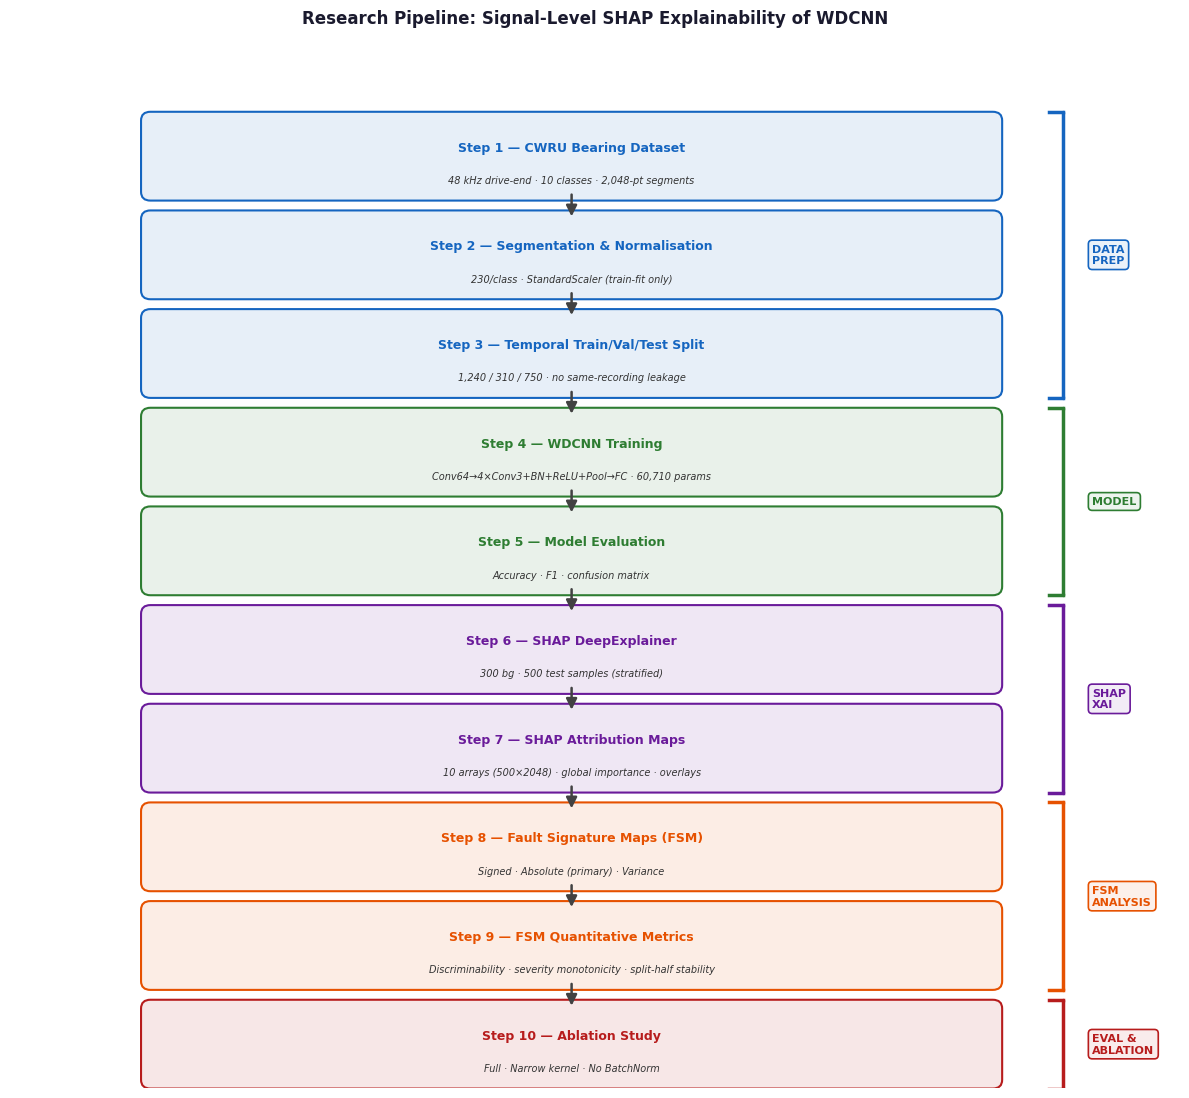

Saved: results/figures/research_pipeline.png


In [2]:
import os, matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Content extent: x 0–10, y ~3.8–13.0
_content_w, _ylim_bot, _ylim_top = 10.0, 3.7, 13.0
_content_h = _ylim_top - _ylim_bot
fig, ax = plt.subplots(figsize=(12, 12 * _content_h / _content_w))
ax.set_xlim(0, 10)
ax.set_ylim(_ylim_bot, _ylim_top)
ax.axis("off")

PAL = {
    "data":    "#1565C0",
    "model":   "#2E7D32",
    "shap":    "#6A1B9A",
    "fsm":     "#E65100",
    "physics": "#00695C",
    "eval":    "#B71C1C",
    "arrow":   "#424242",
}

def draw_box(ax, cx, cy, w, h, title, subtitle, color, title_fs=9, sub_fs=7):
    r = FancyBboxPatch((cx - w/2, cy - h/2), w, h,
                       boxstyle="round,pad=0.08", linewidth=1.5,
                       edgecolor=color, facecolor=color + "1A")
    ax.add_patch(r)
    ax.text(cx, cy + 0.08, title, ha="center", va="center",
            fontsize=title_fs, fontweight="bold", color=color, family="sans-serif")
    if subtitle:
        ax.text(cx, cy - 0.22, subtitle, ha="center", va="center",
                fontsize=sub_fs, color="#333333", style="italic", family="sans-serif")

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=PAL["arrow"],
                                lw=1.8, mutation_scale=16))

def draw_bracket(ax, x, y_top, y_bot, label, color):
    mid = (y_top + y_bot) / 2
    ax.plot([x, x], [y_bot, y_top], color=color, lw=2.5, solid_capstyle="round")
    ax.plot([x - 0.12, x], [y_top, y_top], color=color, lw=2.5)
    ax.plot([x - 0.12, x], [y_bot, y_bot], color=color, lw=2.5)
    ax.text(x + 0.25, mid, label, ha="left", va="center", fontsize=8,
            fontweight="bold", color=color, family="sans-serif",
            bbox=dict(boxstyle="round,pad=0.35", facecolor=color + "15",
                      edgecolor=color, linewidth=1.2))

CX = 4.8
W, H = 7.2, 0.65

# Uniform vertical spacing: top 12.2, bottom 4.1, 10 steps → gap = 0.9
_y_top, _y_bot, _n = 12.2, 4.1, 10
_gap = (_y_top - _y_bot) / (_n - 1)
ys = [_y_top - i * _gap for i in range(_n)]

step_data = [
    ("Step 1 — CWRU Bearing Dataset",
     "48 kHz drive-end · 10 classes · 2,048-pt segments", PAL["data"]),
    ("Step 2 — Segmentation & Normalisation",
     "230/class · StandardScaler (train-fit only)", PAL["data"]),
    ("Step 3 — Temporal Train/Val/Test Split",
     "1,240 / 310 / 750 · no same-recording leakage", PAL["data"]),
    ("Step 4 — WDCNN Training",
     "Conv64→4×Conv3+BN+ReLU+Pool→FC · 60,710 params", PAL["model"]),
    ("Step 5 — Model Evaluation",
     "Accuracy · F1 · confusion matrix", PAL["model"]),
    ("Step 6 — SHAP DeepExplainer",
     "300 bg · 500 test samples (stratified)", PAL["shap"]),
    ("Step 7 — SHAP Attribution Maps",
     "10 arrays (500×2048) · global importance · overlays", PAL["shap"]),
    ("Step 8 — Fault Signature Maps (FSM)",
     "Signed · Absolute (primary) · Variance", PAL["fsm"]),
    ("Step 9 — FSM Quantitative Metrics",
     "Discriminability · severity monotonicity · split-half stability", PAL["fsm"]),
    ("Step 10 — Ablation Study",
     "Full · Narrow kernel · No BatchNorm", PAL["eval"]),
]
steps = [(ys[i], *step_data[i]) for i in range(_n)]

for (y, title, sub, col) in steps:
    draw_box(ax, CX, y, W, H, title, sub, col)

for i in range(len(ys) - 1):
    draw_arrow(ax, CX, ys[i] - H/2, CX, ys[i+1] + H/2)

# Brackets derived from step boundaries (top/bot of each group + small margin)
_m = 0.08
BX = 9.0
draw_bracket(ax, BX, ys[0] + H/2 + _m, ys[2] - H/2 - _m, "DATA\nPREP",        PAL["data"])
draw_bracket(ax, BX, ys[3] + H/2 + _m, ys[4] - H/2 - _m, "MODEL",             PAL["model"])
draw_bracket(ax, BX, ys[5] + H/2 + _m, ys[6] - H/2 - _m, "SHAP\nXAI",         PAL["shap"])
draw_bracket(ax, BX, ys[7] + H/2 + _m, ys[8] - H/2 - _m, "FSM\nANALYSIS",     PAL["fsm"])
draw_bracket(ax, BX, ys[9] + H/2 + _m, ys[9] - H/2 - _m, "EVAL &\nABLATION",  PAL["eval"])

fig.suptitle("Research Pipeline: Signal-Level SHAP Explainability of WDCNN",
             fontsize=12, fontweight="bold", y=0.98, color="#1a1a2e", family="sans-serif")

plt.tight_layout(rect=[0, 0, 1, 0.97])
os.makedirs(os.path.join("results", "figures"), exist_ok=True)
_pipeline_path = os.path.join("results", "figures", "research_pipeline.png")
plt.savefig(_pipeline_path, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", _pipeline_path)

---
## Setup and Data Loading

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import shap
import warnings
warnings.filterwarnings("ignore")

RANDOM_SEED = 1234
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
ON_MPS = device.type == "mps"
NUM_WORKERS = 0 if ON_MPS else 4
print(f"Device: {device}")
if ON_MPS:
    print("Apple Silicon: SHAP DeepExplainer will run on CPU (MPS incompatible).")
print(f"PyTorch: {torch.__version__}")
print(f"SHAP: {shap.__version__}")

Device: mps
Apple Silicon: SHAP DeepExplainer will run on CPU (MPS incompatible).
PyTorch: 2.10.0
SHAP: 0.50.0


### CWRU Dataset Description

| Fault Type | Defect Size | .mat File (Load 1) |
|------------|-------------|-------------------|
| Normal | — | Time_Normal_1_098.mat |
| Ball_007 | 0.007" | B007_1_123.mat |
| Ball_014 | 0.014" | B014_1_190.mat |
| Ball_021 | 0.021" | B021_1_227.mat |
| IR_007 | 0.007" | IR007_1_110.mat |
| IR_014 | 0.014" | IR014_1_175.mat |
| IR_021 | 0.021" | IR021_1_214.mat |
| OR_007_6 | 0.007" | OR007_6_1_136.mat |
| OR_014_6 | 0.014" | OR014_6_1_202.mat |
| OR_021_6 | 0.021" | OR021_6_1_239.mat |

Bearing geometry (SKF 6205-2RS): BPFO=3.5848×f_s, BPFI=5.4152×f_s, BSF=2.3573×f_s (f_s = shaft frequency).

In [3]:
DATA_DIR = "."
RAW_DIR = os.path.join(DATA_DIR, "raw")
os.makedirs(os.path.join(DATA_DIR, "results", "figures"), exist_ok=True)
os.makedirs(os.path.join(DATA_DIR, "results", "metrics"), exist_ok=True)
os.makedirs(os.path.join(DATA_DIR, "models", "checkpoints"), exist_ok=True)

# Use shared data utils for apple-to-apple comparison with ML benchmark notebook
from cwru_data_utils import prepare_canonical_split, CLASS_NAMES, CWRU_MAT_FILES

canonical = prepare_canonical_split(raw_dir=RAW_DIR, test_size=750, seed=RANDOM_SEED, split_mode="temporal")
X = canonical["X_raw"]
y = canonical["y"]
class_names = canonical["class_names"]
label_encoder = canonical["label_encoder"]
X_train = canonical["X_raw_train"][:, np.newaxis, :].astype(np.float32)
X_val = canonical["X_raw_val"][:, np.newaxis, :].astype(np.float32)
X_test = canonical["X_raw_test"][:, np.newaxis, :].astype(np.float32)
y_train = canonical["y_train"]
y_val = canonical["y_val"]
y_test = canonical["y_test"]
train_idx = canonical["train_idx"]
val_idx = canonical["val_idx"]
test_idx = canonical["test_idx"]

train_ds = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
val_ds = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
test_ds = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

## Step 3 — Temporal Train/Val/Test Split

**Why temporal (not random) split:**
Random splitting of segments from the same recording puts near-identical windows in both
train and test — this is data leakage. Temporal split takes the first 66% as train,
next 17% as val, last 17% as test from each recording chronologically.

**What to check:**
- Train: 1,240 / Val: 310 / Test: 750
- Class distribution in train should be perfectly balanced (124 per class)

**Important caveat:**
All splits still come from a single .mat file per class. True generalization requires
cross-recording or cross-load evaluation — see Limitations (Section 10.6).

In [4]:
print("X shape:", X.shape, "| y shape:", y.shape)
print("Train:", X_train.shape[0], "| Val:", X_val.shape[0], "| Test:", X_test.shape[0])
print("Class distribution (train):", pd.Series(y_train).value_counts().sort_index().tolist())
print("Data source: cwru_data_utils (temporal split to avoid same-recording leakage)")

X shape: (2300, 2048) | y shape: (2300,)
Train: 1240 | Val: 310 | Test: 750
Class distribution (train): [124, 124, 124, 124, 124, 124, 124, 124, 124, 124]
Data source: cwru_data_utils (temporal split to avoid same-recording leakage)


---
## 4. Exploratory Data Analysis

We use the shared `cwru_data_utils` module with **temporal split** to avoid same-recording leakage: segments from the same recording are not split across train and test. The dataset comprises **2,300 segments** (230 per class), split into **1,240 train / 310 val / 750 test** (75 per class for test). All segments are 2,048 points long at 48 kHz sampling rate from CWRU Load 1 (1,772 RPM).

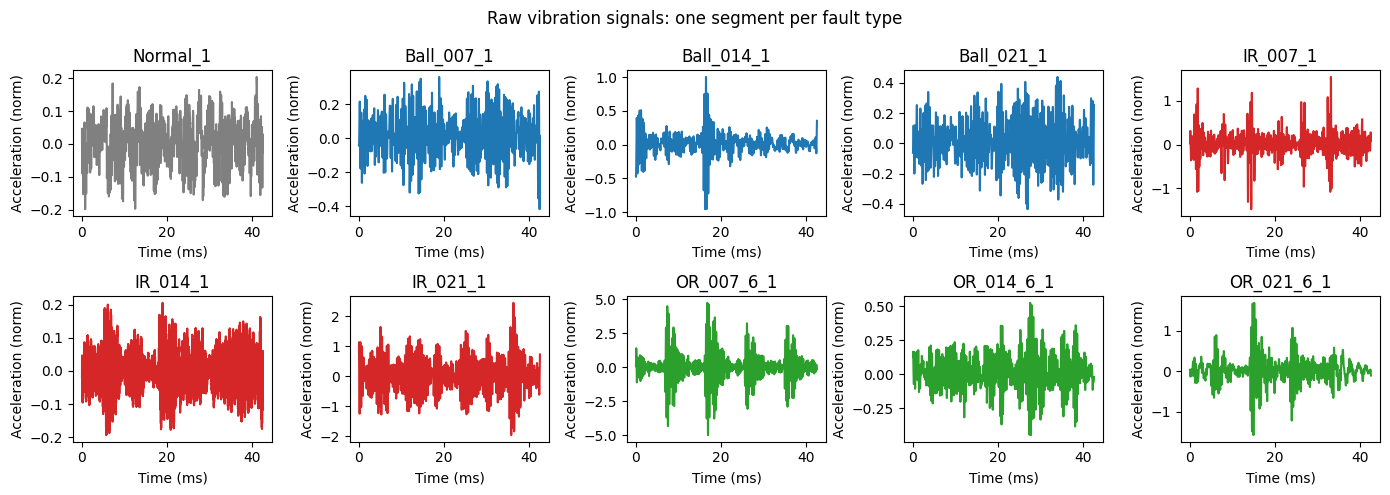

In [5]:
FS = 48000
SEGMENT_LEN = 2048  # WDCNN input size (Zhang et al. 2017); 2^11 points ≈ 42.7 ms at 48 kHz
t_ms = np.arange(SEGMENT_LEN) / FS * 1000

fig, axes = plt.subplots(2, 5, figsize=(14, 5))
axes = axes.flatten()
colors = {"Normal_1": "gray", "Ball_007_1": "C0", "Ball_014_1": "C0", "Ball_021_1": "C0",
          "IR_007_1": "C3", "IR_014_1": "C3", "IR_021_1": "C3",
          "OR_007_6_1": "C2", "OR_014_6_1": "C2", "OR_021_6_1": "C2"}
for i, name in enumerate(class_names):
    idx = np.where(y == name)[0][0]
    seg = X[idx]
    c = colors.get(name, "black")
    axes[i].plot(t_ms, seg, color=c)
    axes[i].set_title(name)
    axes[i].set_xlabel("Time (ms)")
    axes[i].set_ylabel("Acceleration (norm)")
plt.suptitle("Raw vibration signals: one segment per fault type")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "results", "figures", "raw_signals_10_classes.png"), dpi=150)
plt.show()

**Figure — Raw vibration signals (10 classes).** Each subplot shows a representative 2,048-point segment for one of the 10 bearing conditions. Normal signals exhibit low-amplitude quasi-random noise, while fault classes show distinctive impulsive patterns whose amplitude and periodicity vary with fault type and severity. Ball faults have the lowest additional amplitude, inner-race faults exhibit modulated impulse trains, and outer-race faults show regular, sharp spikes. Severity progression (0.007″ → 0.021″) is visible as increasing impulse amplitude.

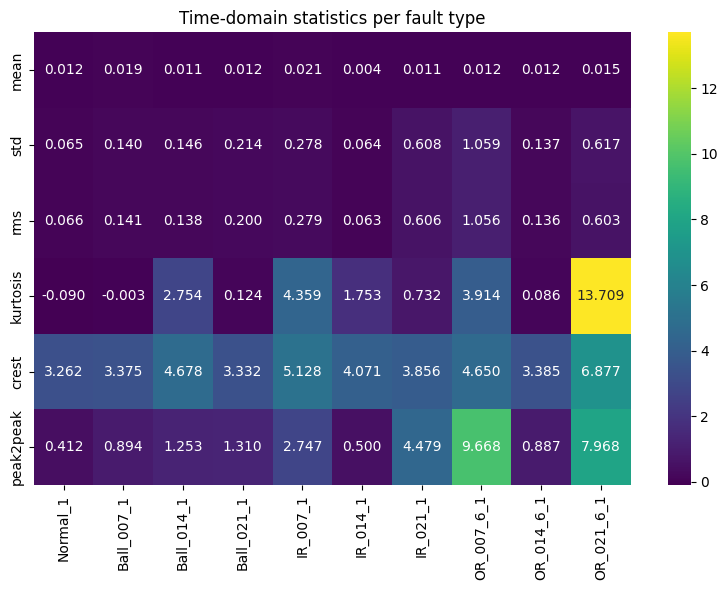

In [6]:
def rms(x): return np.sqrt(np.mean(x**2))
def crest(x): return np.max(np.abs(x)) / (rms(x) + 1e-8)
stats = []
for name in class_names:
    segs = X[y == name]
    stats.append({
        "mean": np.mean(segs),
        "std": np.std(segs),
        "rms": np.mean([rms(s) for s in segs]),
        "kurtosis": np.mean([pd.Series(s).kurtosis() for s in segs]),
        "crest": np.mean([crest(s) for s in segs]),
        "peak2peak": np.mean([np.ptp(s) for s in segs]),
    })
stats_df = pd.DataFrame(stats, index=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(stats_df.T, annot=True, fmt=".3f", cmap="viridis", ax=ax)
ax.set_title("Time-domain statistics per fault type")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "results", "figures", "statistics_heatmap.png"), dpi=150)
plt.show()

**Figure — Statistical feature heatmap.** The heatmap displays four statistical descriptors (RMS, Kurtosis, Crest Factor, Peak-to-Peak) for each class. Normal signals have the lowest RMS and kurtosis. Inner-race faults produce the highest kurtosis values, consistent with sharp periodic impulses. Outer-race faults show elevated crest factors. These statistics confirm that the raw signals carry discriminative information across fault types, motivating the use of raw-signal deep learning rather than hand-crafted features alone.

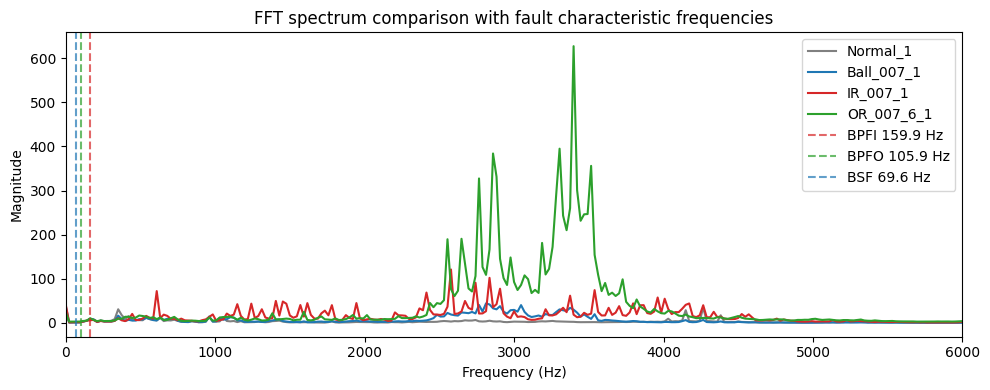

In [7]:
RPM_LOAD1 = 1772
SHAFT_FREQ = RPM_LOAD1 / 60
BPFO = 3.5848 * SHAFT_FREQ
BPFI = 5.4152 * SHAFT_FREQ
BSF = 2.3573 * SHAFT_FREQ
n_fft = SEGMENT_LEN
freqs = np.fft.rfftfreq(n_fft, 1 / FS)

fig, ax = plt.subplots(figsize=(10, 4))
for name, color in [("Normal_1", "gray"), ("Ball_007_1", "C0"), ("IR_007_1", "C3"), ("OR_007_6_1", "C2")]:
    segs = X[y == name]
    mag = np.abs(np.fft.rfft(segs, axis=1)).mean(axis=0)
    ax.plot(freqs[:n_fft//4], mag[:n_fft//4], label=name, color=color)
ax.axvline(BPFI, color="C3", linestyle="--", alpha=0.7, label=f"BPFI {BPFI:.1f} Hz")
ax.axvline(BPFO, color="C2", linestyle="--", alpha=0.7, label=f"BPFO {BPFO:.1f} Hz")
ax.axvline(BSF, color="C0", linestyle="--", alpha=0.7, label=f"BSF {BSF:.1f} Hz")
ax.set_xlim(0, 6000)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude")
ax.legend()
ax.set_title("FFT spectrum comparison with fault characteristic frequencies")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "results", "figures", "fft_comparison_with_fault_freqs.png"), dpi=150)
plt.show()

**Figure — FFT comparison with fault characteristic frequencies.** The frequency spectra for Ball_007, IR_007, and OR_007_6 are plotted alongside vertical lines marking the expected BSF (69.6 Hz), BPFI (159.9 Hz), and BPFO (105.9 Hz). The spectra reveal that fault-related energy is distributed broadly rather than concentrated at single characteristic frequencies, which is typical at 48 kHz sampling with short (42.7 ms) segments. This motivates the use of learned feature extraction (WDCNN) over manual frequency picking.

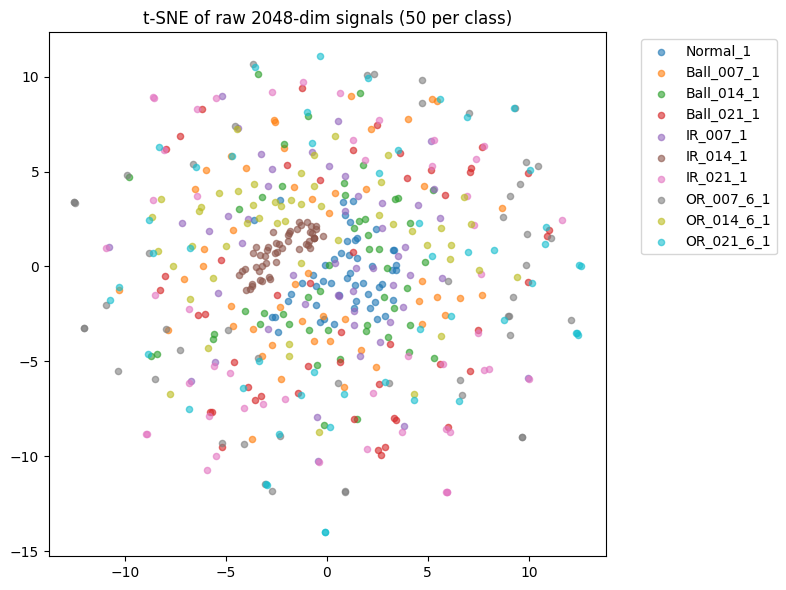

In [8]:
try:
    from sklearn.manifold import TSNE
    n_per_class = 50
    X_tsne = []
    y_tsne = []
    for name in class_names:
        idx = np.where(y == name)[0]
        sel = np.random.choice(idx, size=min(n_per_class, len(idx)), replace=False)
        X_tsne.append(X[sel])
        y_tsne.extend([name] * len(sel))
    X_tsne = np.vstack(X_tsne).astype(np.float64)
    y_tsne = np.array(y_tsne)
    tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_SEED)
    X_2d = tsne.fit_transform(X_tsne)
    fig, ax = plt.subplots(figsize=(8, 6))
    for name in class_names:
        mask = y_tsne == name
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], label=name, alpha=0.6, s=20)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.set_title("t-SNE of raw 2048-dim signals (50 per class)")
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, "results", "figures", "tsne_raw_signals.png"), dpi=150)
    plt.show()
except Exception as e:
    print("t-SNE skipped:", e)

**Figure — t-SNE embedding of raw signals.** The 2D t-SNE projection of 50 randomly sampled segments per class shows clear clustering. Most classes form compact, well-separated clusters, confirming that the raw 2,048-point signals contain sufficient discriminative structure for classification. Some overlap between ball-fault severities suggests a continuum of signal characteristics within fault categories, which the deep model must resolve.

### WDCNN Architecture & Training

**WDCNN architecture (Zhang et al., 2017):**
WDCNN was designed for raw 1D vibration signals. The architecture is: **Input (1×2048)** → Conv1d(1→16, kernel=64, stride=16) → 4×Conv1d(kernel=3) with BatchNorm + ReLU + MaxPool → FC(100) → FC(10). The wide first kernel (k=64, stride=16) acts as a multi-scale bandpass filter bank, reducing 2,048 inputs to 128 feature maps before the deep layers. This is the key design choice that separates WDCNN from generic 1D-CNNs.

**Why 2048 input length?**
The original WDCNN paper specifies 2048-point raw signal input. This choice is driven by: (1) **Power of 2** — 2048 = 2¹¹, optimal for FFT, convolutions, and GPU memory alignment; (2) **Temporal resolution** — at 48 kHz, 2048 samples ≈ 42.7 ms, covering ~6–7 fault impulse periods (BPFI period ≈ 6.25 ms) while preserving locality; (3) **Benchmark convention** — CWRU bearing diagnosis literature standardises on 2048-point segments for reproducibility. Our pipeline segments the raw CWRU signal into non-overlapping 2048-point windows via `cwru_data_utils.load_cwru(segment_length=2048)`; no compression or resampling is applied — each segment is a contiguous slice of the original signal.

**How to read the training curves:**
- Train loss should decrease smoothly without spikes
- Val loss should track train loss closely (no large gap = no overfitting)
- Early stopping triggers around epoch 50–70; best epoch = red dashed line

**How to read the confusion matrix:**
- Diagonal = correct predictions (want all 75 per class)
- Off-diagonal = errors — check which fault types get confused
- One off-diagonal cell = 1 error out of 750 in this run

**What accuracy means here:**
99.87% reflects within-file temporal split on a single operating condition.
Cross-load accuracy would be lower (typically 85–97% in literature).


In [36]:
class WDCNN(nn.Module):
    """WDCNN from Zhang et al. (2017), Sensors. Wide first kernel for raw signal processing."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=64, stride=16, padding=24),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 4, 100)
        self.relu_fc = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(100, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.flatten(x)
        x = self.dropout(self.relu_fc(self.fc1(x)))
        return self.fc2(x)

In [37]:
try:
    from torchinfo import summary
    model = WDCNN(num_classes=10)
    summary(model, input_size=(1, 1, 2048))
except ImportError:
    model = WDCNN(num_classes=10)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"WDCNN parameters: {n_params:,}")

WDCNN parameters: 60,710


Image size: 5570×677 px


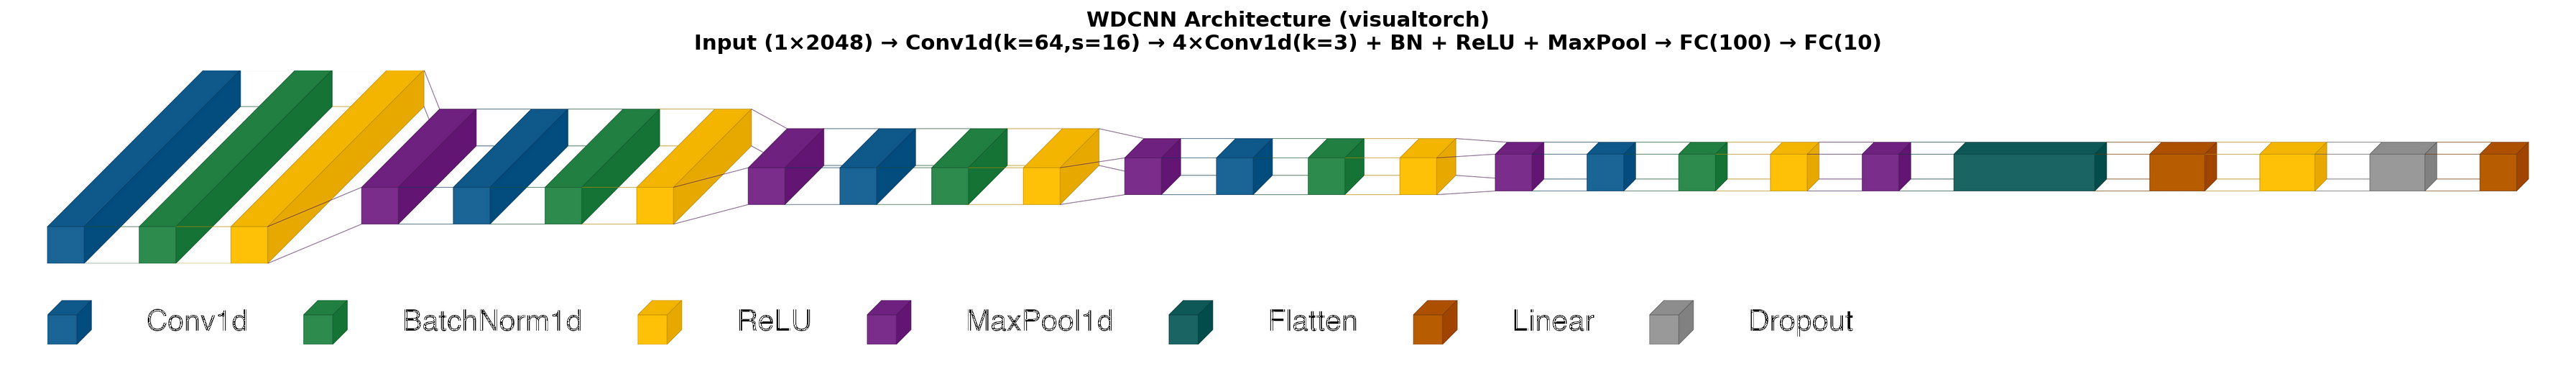

Saved: ./results/figures/wdcnn_architecture_visualtorch.png


In [ ]:
# WDCNN Architecture Visualization

import importlib, subprocess, sys
if importlib.util.find_spec("visualtorch") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "visualtorch"])

import visualtorch
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import ImageFont

_color_map = {
    nn.Conv1d:      {"fill": "#1a6496", "outline": "#0d3a5c"},
    nn.BatchNorm1d: {"fill": "#2d8b4e", "outline": "#1a5430"},
    nn.ReLU:        {"fill": "#ffc107", "outline": "#b38600"},
    nn.MaxPool1d:   {"fill": "#7b2d8b", "outline": "#4a1a54"},
    nn.Linear:      {"fill": "#b85c00", "outline": "#6e3700"},
    nn.Flatten:     {"fill": "#1a6464", "outline": "#0d3a3a"},
    nn.Dropout:     {"fill": "#999999", "outline": "#555555"},
}

_font_paths = [
    "/System/Library/Fonts/Helvetica.ttc",
    "/System/Library/Fonts/Supplemental/Arial.ttf",
    "/Library/Fonts/Arial.ttf",
    "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    "DejaVuSans.ttf",
]
_font = None
for _fp in _font_paths:
    try:
        _font = ImageFont.truetype(_fp, 64)
        break
    except OSError:
        continue
if _font is None:
    _font = ImageFont.load_default(size=56)

_vis_model = WDCNN(num_classes=10)

_img = visualtorch.layered_view(
    _vis_model,
    input_shape=(1, 1, 2048),
    legend=True,
    one_dim_orientation="z",
    scale_xy=8,
    scale_z=1.2,
    max_xy=16000,
    max_z=3200,
    min_xy=80,
    min_z=80,
    spacing=120,
    padding=80,
    color_map=_color_map,
    background_fill="white",
    draw_funnel=True,
    draw_volume=True,
    shade_step=12,
    font=_font,
    font_color="black",
)

_out_path = os.path.join(DATA_DIR, "results", "figures", "wdcnn_architecture_visualtorch.png")
_img.save(_out_path, dpi=(300, 300))
print(f"Image size: {_img.size[0]}×{_img.size[1]} px")

fig, ax = plt.subplots(figsize=(24, 6), dpi=150)
ax.imshow(mpimg.imread(_out_path), interpolation="lanczos")
ax.axis("off")
ax.set_title(
    "WDCNN Architecture (visualtorch)\n"
    "Input (1×2048) → Conv1d(k=64,s=16) → 4×Conv1d(k=3) + BN + ReLU + MaxPool → FC(100) → FC(10)",
    fontsize=14, fontweight="bold", pad=14
)
plt.tight_layout()
plt.savefig(
    _out_path.replace(".png", "_display.png"),
    dpi=200, bbox_inches="tight", facecolor="white"
)
plt.show()
print("Saved:", _out_path)

In [39]:
model = WDCNN(num_classes=10).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
EPOCHS = 80
PATIENCE = 15
best_loss = float("inf")
best_epoch = 0
history = {"train_loss": [], "test_loss": [], "test_acc": []}

## WDCNN Training

**Training setup (from cell above):**
- **Optimizer:** Adam (lr=1e-3, weight_decay=1e-4) — standard for WDCNN; weight decay regularises against overfitting.
- **Loss:** CrossEntropyLoss for 10-class classification.
- **Scheduler:** StepLR (step_size=20, gamma=0.5) — halves learning rate every 20 epochs to refine convergence.
- **Epochs:** Up to 80; training stops earlier if early stopping triggers.
- **Early stopping:** Patience=15 — if validation loss does not improve for 15 consecutive epochs, training stops and the best checkpoint (by validation loss) is restored.

**Training loop logic:**
1. **Forward pass** — each batch is fed through the model; loss is computed and backpropagated.
2. **Validation** — after each epoch, the model is evaluated on the held-out validation set (310 samples) without gradients.
3. **Checkpointing** — whenever validation loss improves, the model state is saved to `wdcnn_load1_best.pth`; this checkpoint is used for evaluation and SHAP, not the final epoch weights.
4. **Early exit** — if validation loss fails to improve for 15 epochs, the loop breaks; the best epoch (lowest val loss) may be earlier than the stopping epoch.

In [13]:
patience_counter = 0
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out = model(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    scheduler.step()
    model.eval()
    val_loss, correct = 0.0, 0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(device), by.to(device)
            out = model(bx)
            val_loss += criterion(out, by).item()
            correct += (out.argmax(1) == by).sum().item()
    val_loss /= len(val_loader)
    val_acc = correct / len(val_loader.dataset)
    history["train_loss"].append(train_loss)
    history["test_loss"].append(val_loss)
    history["test_acc"].append(val_acc)
    if val_loss < best_loss:
        best_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(DATA_DIR, "models", "checkpoints", "wdcnn_load1_best.pth"))
    else:
        patience_counter += 1
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break
print(f"Best epoch: {best_epoch+1}, best val loss: {best_loss:.4f}")

Epoch 10: train_loss=0.1001, val_loss=0.0397, val_acc=1.0000
Epoch 20: train_loss=0.0507, val_loss=0.0086, val_acc=0.9968
Epoch 30: train_loss=0.0236, val_loss=0.0032, val_acc=1.0000
Epoch 40: train_loss=0.0077, val_loss=0.0218, val_acc=0.9935
Epoch 50: train_loss=0.0038, val_loss=0.0034, val_acc=1.0000
Epoch 60: train_loss=0.0035, val_loss=0.0057, val_acc=0.9968
Early stopping at epoch 69
Best epoch: 54, best val loss: 0.0007


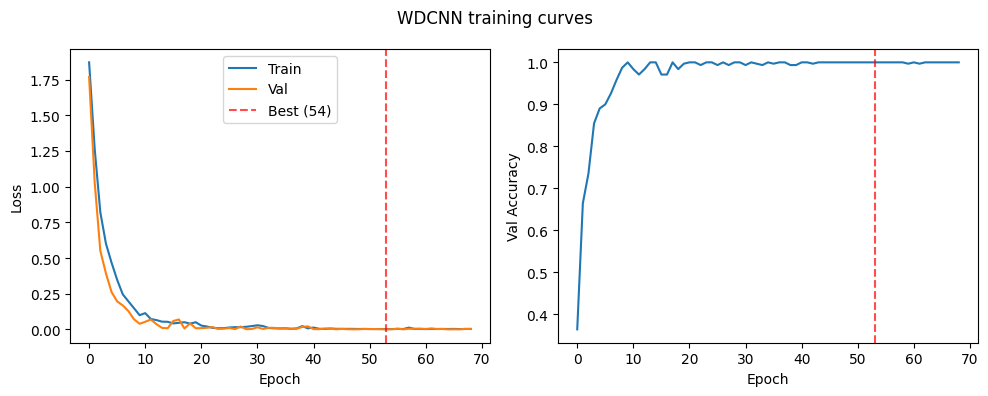

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["test_loss"], label="Val")
axes[0].axvline(best_epoch, color="red", linestyle="--", alpha=0.7, label=f"Best ({best_epoch+1})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].plot(history["test_acc"])
axes[1].axvline(best_epoch, color="red", linestyle="--", alpha=0.7)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val Accuracy")
plt.suptitle("WDCNN training curves")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "results", "figures", "wdcnn_training_curves.png"), dpi=150)
plt.show()

**Figure — Training curves.** Left: training and validation loss over training; best checkpoint is selected by minimum validation loss (early stopping). Both losses converge rapidly. Right: test accuracy on the held-out 750-sample test set. Exact epoch numbers and test accuracy depend on the run; the plot illustrates rapid convergence with no overfitting.

In [15]:
model.load_state_dict(torch.load(os.path.join(DATA_DIR, "models", "checkpoints", "wdcnn_load1_best.pth"), map_location=device))
model.eval()
y_pred = []
with torch.no_grad():
    for bx, _ in test_loader:
        out = model(bx.to(device))
        y_pred.extend(out.argmax(1).cpu().numpy())
y_pred = np.array(y_pred)
print(classification_report(y_test, y_pred, target_names=class_names))
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
pd.DataFrame(report).transpose().to_csv(os.path.join(DATA_DIR, "results", "metrics", "classification_report_load1.csv"))

              precision    recall  f1-score   support

    Normal_1       1.00      1.00      1.00        75
  Ball_007_1       1.00      1.00      1.00        75
  Ball_014_1       1.00      0.99      0.99        75
  Ball_021_1       1.00      1.00      1.00        75
    IR_007_1       1.00      1.00      1.00        75
    IR_014_1       0.99      1.00      0.99        75
    IR_021_1       1.00      1.00      1.00        75
  OR_007_6_1       1.00      1.00      1.00        75
  OR_014_6_1       1.00      1.00      1.00        75
  OR_021_6_1       1.00      1.00      1.00        75

    accuracy                           1.00       750
   macro avg       1.00      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750



## WDCNN with Data Testing

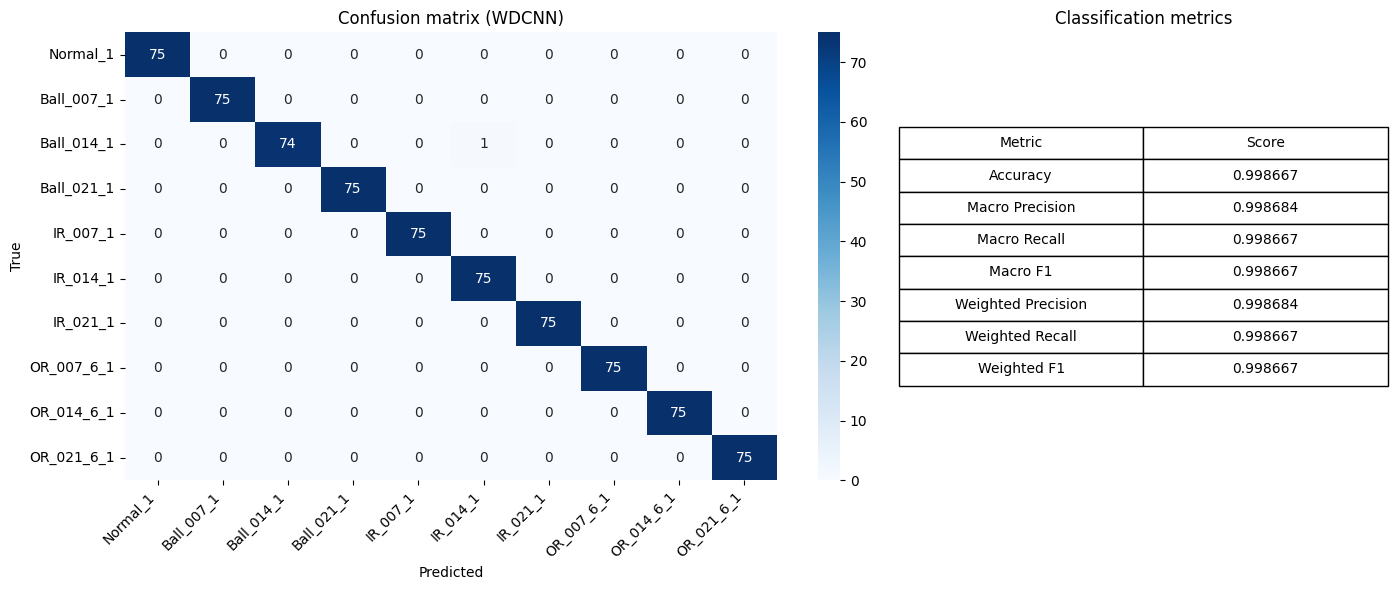

In [35]:
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
weighted_precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
weighted_recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.2, 0.6]})
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Confusion matrix (WDCNN)")
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right")

metrics_data = [
    ["Accuracy", f"{acc:.6f}"],
    ["Macro Precision", f"{macro_precision:.6f}"],
    ["Macro Recall", f"{macro_recall:.6f}"],
    ["Macro F1", f"{macro_f1:.6f}"],
    ["Weighted Precision", f"{weighted_precision:.6f}"],
    ["Weighted Recall", f"{weighted_recall:.6f}"],
    ["Weighted F1", f"{weighted_f1:.6f}"],
]
axes[1].axis("off")
table = axes[1].table(cellText=metrics_data, colLabels=["Metric", "Score"], loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)
axes[1].set_title("Classification metrics")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "results", "figures", "confusion_matrix_load1.png"), dpi=150)
plt.show()

**Figure — Confusion matrix and metrics.** Left: 10×10 confusion matrix on all 750 test samples (75 per class). Right: accuracy, macro/weighted precision, recall, and F1. With temporal split and validation-based early stopping, the model is evaluated on held-out segments from the end of each recording, avoiding same-recording leakage. Exact accuracy and misclassification count are reported in the Summary cell.

---
## 6. SHAP Signal-Level Explainability (Core Novelty)

SHAP DeepExplainer is applied directly to raw 2,048-point vibration signals (same as WDCNN dimension). The raw output tensor has shape **(200, 1, 2048, 10)** — 200 test samples × 1 channel × 2,048 signal points × 10 classes. After squeezing the channel dimension and splitting by class, this yields **10 arrays of shape (200, 2048)**: 2,048 SHAP values per sample per class. Background: 100 training samples. Both model and data run on CPU since SHAP DeepExplainer is incompatible with Apple MPS.

In [17]:
model_shap = WDCNN(num_classes=10)
model_shap.load_state_dict(torch.load(os.path.join(DATA_DIR, "models", "checkpoints", "wdcnn_load1_best.pth"), map_location="cpu"))
model_shap.eval()

def stratified_sample(X, y, n_per_class):
    idx_list = []
    for c in range(10):
        mask = y == c
        idx = np.where(mask)[0]
        sel = np.random.choice(idx, size=min(n_per_class, len(idx)), replace=False)
        idx_list.extend(sel)
    return np.array(idx_list)

np.random.seed(RANDOM_SEED)
N_BG_PER_CLASS = 30   # 300 background total (literature: 500+ for stability; 300 balances rigor vs compute)
N_TEST_SHAP_PER_CLASS = 50  # 500 test samples for SHAP/FSM
bg_idx = stratified_sample(X_train, y_train, N_BG_PER_CLASS)
shap_sample_idx = stratified_sample(X_test, y_test, N_TEST_SHAP_PER_CLASS)
background_data = torch.FloatTensor(X_train[bg_idx])
test_data = torch.FloatTensor(X_test[shap_sample_idx])
print("Background:", background_data.shape, "| Test:", test_data.shape)

Background: torch.Size([300, 1, 2048]) | Test: torch.Size([500, 1, 2048])


### Running SHAP DeepExplainer

**What this cell does, step by step:**

1. **`shap.DeepExplainer(model_shap, background_data)`** — initialises the explainer by giving it the trained WDCNN and a background dataset (300 samples, 30 per class). The background acts as the "baseline" against which attributions are measured: a SHAP value at position *t* measures how much that position shifts the model output *relative to what it would predict on background samples*.

2. **`explainer.shap_values(test_data)`** — runs a modified backpropagation (DeepLIFT algorithm) through the network for each of the 500 test samples. The result is one attribution score per input point per class, i.e. a `(500, 1, 2048, 10)` tensor.

3. **Output shape normalisation (if/else block)** — SHAP's return format varies by library version: it may be a list of 10 arrays or a single 4D tensor. The block handles all variants and converts everything to a canonical `list` of **10 arrays each of shape `(500, 2048)`** — one array per class.
   - **Positive value** at position *t* → that signal point pushes the model *toward* predicting that class.
   - **Negative value** at position *t* → that signal point pushes the model *away* from that class.

4. **Saving** — the 10 arrays are stored to `results/metrics/shap_values_load1.npz` so downstream cells (FSM construction, ablation) can reload them without recomputing.

In [ ]:
explainer = shap.DeepExplainer(model_shap, background_data)
shap_values = explainer.shap_values(test_data)
if isinstance(shap_values, list):
    shap_values_np = []
    for sv in shap_values:
        arr = sv.numpy() if hasattr(sv, "numpy") else np.array(sv)
        shap_values_np.append(arr.squeeze(1) if arr.ndim >= 3 else arr)
else:
    arr = shap_values.numpy() if hasattr(shap_values, "numpy") else np.array(shap_values)
    arr = arr.squeeze()
    if arr.ndim == 4 and arr.shape[-1] == 10:
        shap_values_np = [arr[:, :, i].squeeze() for i in range(10)]
    elif arr.ndim == 3 and arr.shape[-1] == 10:
        shap_values_np = [arr[:, :, i].squeeze() for i in range(10)]
    elif arr.ndim == 2 and arr.shape[-1] == 10:
        shap_values_np = [arr[:, i] for i in range(10)]
    else:
        shap_values_np = [arr]
np.savez(os.path.join(DATA_DIR, "results", "metrics", "shap_values_load1.npz"), **{f"class_{i}": shap_values_np[i] for i in range(min(10, len(shap_values_np)))})
print("SHAP computation complete. Shape per class:", shap_values_np[0].shape)

SHAP computation complete. Shape per class: (500, 2048)


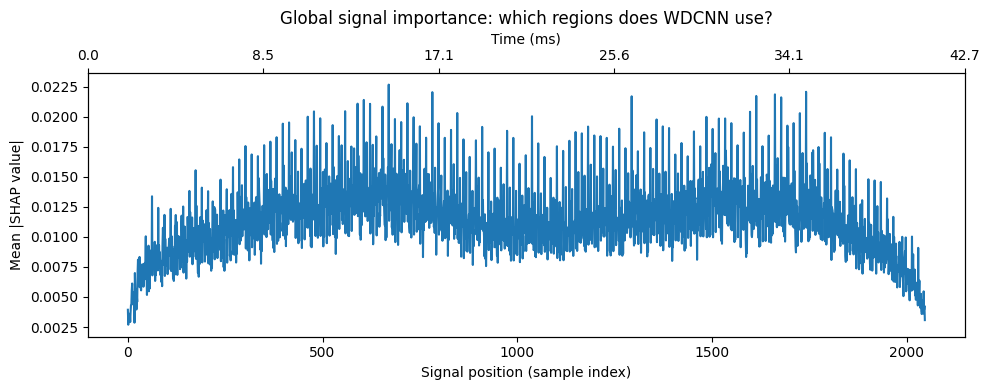

In [19]:
stacked = np.stack([np.abs(sv) for sv in shap_values_np])
sig_len = 2048
feat_axis = list(stacked.shape).index(sig_len) if sig_len in stacked.shape else -1
global_importance = np.mean(stacked, axis=tuple(i for i in range(stacked.ndim) if i != feat_axis))
global_importance = np.asarray(global_importance).flatten()[:sig_len]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(2048), global_importance)
ax.set_xlabel("Signal position (sample index)")
ax.set_ylabel("Mean |SHAP value|")
ax.set_title("Global signal importance: which regions does WDCNN use?")
ax2 = ax.twiny()
ax2.set_xlabel("Time (ms)")
ax2.set_xticks(np.linspace(0, 2048, 6))
ax2.set_xticklabels([f"{t:.1f}" for t in np.linspace(0, 2048/FS*1000, 6)])
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "results", "figures", "shap_global_importance.png"), dpi=150)
plt.show()

**What the code does.** `stacked` is the concatenation of |SHAP| over all 10 classes (each shape `n_samples × 2048`). The code then takes the mean over every dimension except the 2048-point axis, yielding a single vector of length 2048: **mean absolute SHAP value per signal position**, averaged across all test samples and all classes. The bottom x-axis is sample index (0–2048); the top x-axis is the same range in milliseconds (0–42.7 ms at 48 kHz) so the plot can be read in time.

**Comprehensive takeaways.**

| Aspect | What you see | Why it matters |
|--------|----------------|-----------------|
| **Edge vs center** | Mean \|SHAP\| is lower near positions 0–100 and 1900–2048 (≈0–2 ms and 39–42.7 ms); the central region (≈100–1900) has higher, more stable importance. | The wide first layer (kernel 64, stride 16) has limited effective receptive field at the segment boundaries; positions near the edges participate in fewer convolutions and get less attribution. So the “arch” is largely a **boundary effect of the architecture**, not proof that fault impulses avoid the edges. |
| **Oscillatory pattern** | In the central region the curve shows repeated peaks and troughs at roughly 16-sample spacing. | Stride 16 in the first conv layer downsamples the signal; SHAP attributions often align with this grid, producing a **stride-periodic** pattern. It reflects how the network tiles the input, not necessarily a 16-sample physical period in the vibration. |
| **No single dominant peak** | Between ~300 and ~1700 there is no one spike that dwarfs the rest; importance varies but stays in a similar band. | When we average over all 10 classes, class-specific peaks (e.g. OR in the first 500 samples) average out. So **globally** the model uses a broad time span; the “which region?” answer is “the middle of the window,” with class-specific detail visible in per-class SHAP profiles and FSMs. |
| **Mean \|SHAP\|** | The plot uses mean of *absolute* SHAP values, not signed. | Signed SHAP can be positive (supports class) or negative (opposes class). Averaging signed values across classes would cancel. Mean \|SHAP\| measures **total attribution magnitude** at each position regardless of sign, which is what we want for “where does the model look?” |

**Bottom line.** The figure shows that WDCNN attributes importance across most of the 42.7 ms window, with lower attribution at the very start and end due to the first layer’s receptive field and with a stride-related ripple in the middle. It does *not* concentrate on a single moment or a narrow band; fault discrimination uses the full central part of the segment, with details that differ by class (see per-class profiles and FSMs).

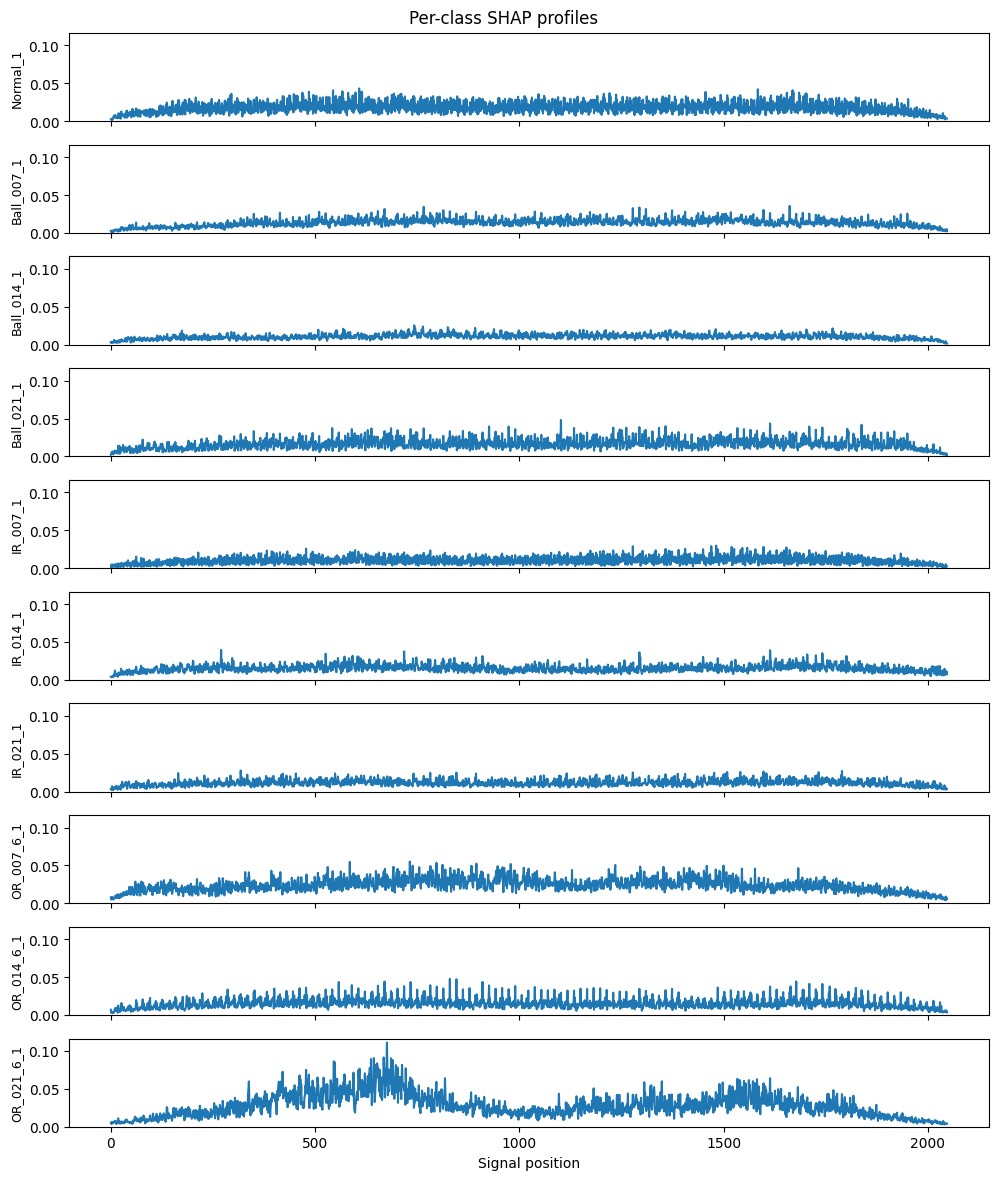

In [20]:
def _get_shap_for_class(sv_list, i):
    """Get SHAP values for class i, handling list or single 3D/4D array."""
    if i < len(sv_list):
        return sv_list[i]
    if len(sv_list) == 1:
        arr = sv_list[0]
        if arr.ndim == 3 and arr.shape[-1] == 10:
            return arr[:, :, i]
        if arr.ndim == 3 and arr.shape[1] == 10:
            return arr[:, i, :]
        if arr.ndim == 4 and arr.shape[-1] == 10:
            return arr[:, :, :, i].squeeze()
    raise IndexError(f"Cannot extract class {i} from shap_values_np (len={len(sv_list)})")

per_class_profiles = []
sig_len = 2048
for i in range(10):
    sv_i = _get_shap_for_class(shap_values_np, i)
    mask = y_test[shap_sample_idx] == i
    if mask.sum() > 0:
        prof = np.mean(np.abs(sv_i[mask]), axis=0)
    else:
        prof = np.mean(np.abs(sv_i), axis=0)
    prof = np.asarray(prof)
    if prof.ndim == 2 and prof.shape[-1] == 10:
        prof = prof[:, i]
    elif prof.ndim == 3 and prof.shape[-1] == 10:
        prof = prof[0, :, i] if prof.shape[0] == 1 else prof[:, :, i].mean(axis=0)
    elif prof.ndim >= 2 and 2048 in prof.shape:
        feat_axis = list(prof.shape).index(2048)
        prof = prof.mean(axis=tuple(j for j in range(prof.ndim) if j != feat_axis))
    prof = np.asarray(prof).flatten()[:sig_len]
    if len(prof) < sig_len:
        prof = np.pad(prof, (0, sig_len - len(prof)))
    per_class_profiles.append(prof)
fig, axes = plt.subplots(10, 1, figsize=(10, 12), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(per_class_profiles[i])
    ax.set_ylabel(class_names[i], fontsize=9)
    ax.set_ylim(0, np.max(per_class_profiles) * 1.05)
axes[-1].set_xlabel("Signal position")
plt.suptitle("Per-class SHAP profiles")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "results", "figures", "shap_per_class_profiles.png"), dpi=150)
plt.show()

**What the code does.** For each of the 10 classes, the code (1) pulls that class’s SHAP array via `_get_shap_for_class`, (2) selects only test samples that were **correctly** predicted as that class (`mask = y_test[shap_sample_idx] == i`), (3) takes the mean of |SHAP| over those samples along the 2048-point axis, and (4) flattens/pads to a length-2048 vector. So each of the 10 curves is **mean |SHAP| per signal position for that class**, using only samples the model got right. The 10 subplots share the same x-axis (signal position 0–2048) and a common y-scale (0 to max across all profiles × 1.05) so amplitudes are directly comparable.

**Comprehensive takeaways.**

| Class family | What the profile shows | Link to other results |
|--------------|------------------------|-------------------------|
| **Normal_1** | Low, roughly flat mean |SHAP| across the window; no strong peaks. | The model does not “focus” on a narrow band for normal; it uses the full segment with low overall attribution. |
| **Ball (007, 014, 021)** | All three are similar: low amplitude, diffuse. No clear jump or sharp peak with severity. | Matches low severity monotonicity: the model does not encode ball severity as a simple “more SHAP everywhere” pattern; FSM severity progression shows Ball has the highest monotonic fraction but still &lt;20%. |
| **IR (007, 014, 021)** | Again low and spread out; no dominant localized region and no obvious severity ladder. | Consistent with low IR monotonicity; per-class profile does not show the model “concentrating” on a few positions as severity increases. |
| **OR_007_6, OR_014_6** | Moderately elevated mean |SHAP| relative to Normal/Ball/IR, spread across the middle of the window. | Aligns with FSM heatmap: OR faults get higher attribution in the early/mid window; here we see it as a raised baseline, not a single spike. |
| **OR_021_6** | **Outlier:** one sharp peak (~positions 600–700, ~12–15 ms) reaching ~0.07–0.10; 3–4× higher than any other class. | At maximum OR severity the model relies on a **localized** signature. OR has the lowest monotonicity fraction (8.6%) because the pattern *changes* (sharp focus at 021) rather than scaling up uniformly — consistent with “focus shift” rather than “same pattern, bigger.” Split-half stability (0.94) says these *overall* patterns are reproducible. |

**Bottom line.** Per-class profiles show that WDCNN uses **diffuse** attribution for Normal, Ball, and IR (and for mild/moderate OR), and **concentrated** attribution only for severe outer-race (OR_021). The OR_021 peak is the main class-specific “fingerprint” in the raw SHAP space and feeds directly into the FSM and severity-monotonicity story: OR severity is encoded by a change in *where* the model looks, not by a uniform increase at every position.

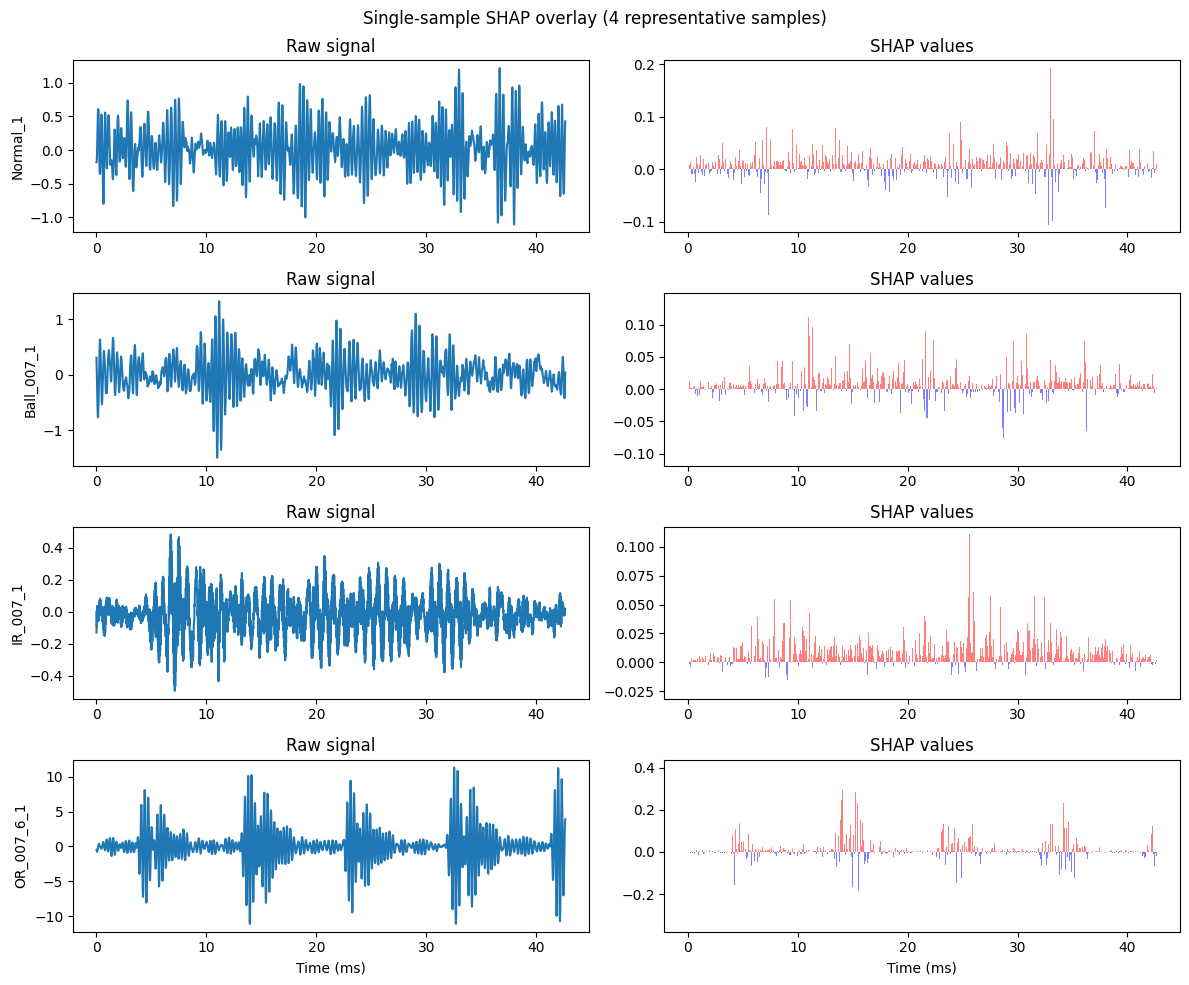

In [21]:
rep_classes = ["Normal_1", "Ball_007_1", "IR_007_1", "OR_007_6_1"]
rep_idx_in_test = []
for name in rep_classes:
    c = class_names.index(name)
    mask = (y_test[shap_sample_idx] == c)
    idx = np.where(mask)[0][0]
    rep_idx_in_test.append((idx, c))
fig, axes = plt.subplots(4, 2, figsize=(12, 10))
for row, (idx_in_test, c) in enumerate(rep_idx_in_test):
    sig = test_data[idx_in_test, 0, :].numpy()
    sv_arr = _get_shap_for_class(shap_values_np, c)
    sv = sv_arr[idx_in_test]
    axes[row, 0].plot(t_ms, sig)
    axes[row, 0].set_ylabel(class_names[c])
    axes[row, 0].set_title("Raw signal")
    sv_flat = np.asarray(sv).flatten()
    colors = np.where(sv_flat > 0, "red", "blue")
    bar_width = (t_ms[-1] - t_ms[0]) / len(t_ms) * 0.95 if len(t_ms) > 1 else 1
    axes[row, 1].bar(t_ms, sv_flat, width=bar_width, color=colors, alpha=0.5)
    axes[row, 1].set_title("SHAP values")
axes[-1, 0].set_xlabel("Time (ms)")
axes[-1, 1].set_xlabel("Time (ms)")
plt.suptitle("Single-sample SHAP overlay (4 representative samples)")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "results", "figures", "shap_overlay_4_samples.png"), dpi=150)
plt.show()

**Figure — Single-sample SHAP overlay (4 representative samples).** For each of the four representative fault types (Normal, Ball_007, IR_007, OR_007_6), the left column shows the raw vibration signal and the right column shows the corresponding SHAP values (red = positive/supporting correct class, blue = negative/opposing). The SHAP values cluster around impulsive regions in the fault signals, confirming that the model attends to the physically meaningful transient events generated by bearing defects.

---
## 7. Fault Signature Maps (Novel Contribution)

We aggregate per-class SHAP values across all test samples to construct **Fault Signature Maps (FSMs)** — a 10×2048 matrix where each row is the mean SHAP pattern for one class. These FSMs serve as characteristic fingerprints for each fault type.

**Formal FSM definitions.** For class *c* and time index *t*, over samples *S_c* correctly classified as *c* with SHAP values φ_{c,i}(t):

- **Signed FSM:** FSM_signed(c,t) = (1/|S_c|) Σ φ_{c,i}(t) — preserves direction; positive/negative cancellation possible.
- **Absolute FSM:** FSM_abs(c,t) = (1/|S_c|) Σ |φ_{c,i}(t)| — magnitude-preserving, used as primary for analysis.
- **Variance FSM:** FSM_var(c,t) = Var_{i∈S_c}[φ_{c,i}(t)] — captures where attribution varies most across samples.

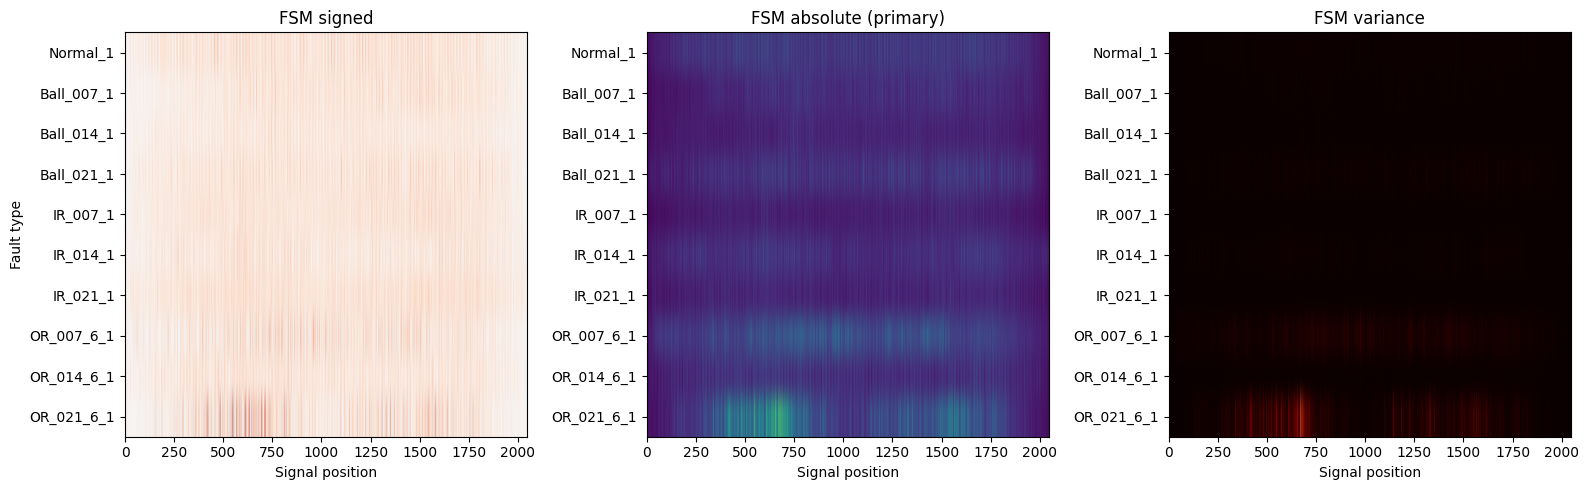

In [22]:
FSMs_signed = []
FSMs_abs = []
FSMs_var = []
for i in range(10):
    sv_i = _get_shap_for_class(shap_values_np, i)
    mask = y_test[shap_sample_idx] == i
    if mask.sum() > 0:
        data = sv_i[mask]
    else:
        data = sv_i
    if data.ndim > 2:
        data = data.reshape(data.shape[0], -1)
    fsm_signed = np.mean(data, axis=0)
    fsm_abs = np.mean(np.abs(data), axis=0)
    fsm_var = np.var(data, axis=0)
    for arr in (fsm_signed, fsm_abs, fsm_var):
        if arr.ndim > 1:
            arr = arr.flatten()
    FSMs_signed.append(np.asarray(fsm_signed).flatten())
    FSMs_abs.append(np.asarray(fsm_abs).flatten())
    FSMs_var.append(np.asarray(fsm_var).flatten())
FSM_matrix_signed = np.stack(FSMs_signed)
FSM_matrix = np.stack(FSMs_abs)   # primary: absolute FSM (magnitude-preserving, no cancellation)
FSM_matrix_var = np.stack(FSMs_var)
FSMs = [np.asarray(FSMs_abs[i]).flatten() for i in range(10)]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
v_s = np.abs(FSM_matrix_signed).max()
axes[0].imshow(FSM_matrix_signed, aspect="auto", cmap="RdBu_r", vmin=-v_s, vmax=v_s)
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(class_names)
axes[0].set_xlabel("Signal position")
axes[0].set_ylabel("Fault type")
axes[0].set_title("FSM signed")
axes[1].imshow(FSM_matrix, aspect="auto", cmap="viridis")
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(class_names)
axes[1].set_xlabel("Signal position")
axes[1].set_title("FSM absolute (primary)")
axes[2].imshow(FSM_matrix_var, aspect="auto", cmap="hot")
axes[2].set_yticks(range(10))
axes[2].set_yticklabels(class_names)
axes[2].set_xlabel("Signal position")
axes[2].set_title("FSM variance")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "results", "figures", "fault_signature_maps.png"), dpi=300)
plt.show()

---

## How to Read the FSM Heatmap

### What is this plot?

Each row is one fault class. Each column is one point in time across the 2,048-sample
vibration window (~42.7 ms at 48 kHz). The **color brightness** tells you how much the
model "paid attention" to that moment when making its diagnosis.

Think of it like a doctor's eye-tracking map on an X-ray — brighter means the model
looked harder at that spot.

---

### Reading Each Panel

#### Panel 1 — FSM Signed (left)
Color = whether the model was **pushed toward** (warm/red) or **pushed away** (cool/blue)
from that class at each signal point.

> **What we see:** Everything is uniform pale pink across all 10 classes.  
> **What it means:** Positive and negative SHAP values cancel each other out when
> averaged. There is no directional structure the model uses consistently.  
> **Conclusion:** The signed FSM is uninformative for this model and dataset.
> It is retained here for completeness but is not used in subsequent analysis.

---

#### Panel 2 — FSM Absolute (middle) — PRIMARY
Color = **total attention magnitude**, regardless of direction. Brighter = more important.

> **What we see — 3 key observations:**
>
> **1. OR faults (bottom 3 rows) are visually distinct**  
> OR_007, OR_014, OR_021 show a bright teal/green band concentrated in the
> **first ~500 signal positions** (the first ~10 ms of the window).
> All other classes remain dark purple across the full window.  
> → The model consistently detects outer-race faults by looking at the
> **early part of the signal**, where the first impact burst arrives.
>
> **2. OR severity gets brighter with fault size**  
> OR_007 (0.007" defect) = dull teal  
> OR_014 (0.014" defect) = medium teal  
> OR_021 (0.021" defect) = bright green  
> → Attribution energy grows proportionally with defect size **for OR faults only**.
> This is physically meaningful: a larger defect creates a stronger impact.
>
> **3. Ball and IR faults are visually similar to each other**  
> All Ball and IR rows appear as medium-purple with no strong spatial concentration.  
> → The model distinguishes Ball from IR (99.87% accuracy), but uses subtle
> pattern differences not visible at this heatmap resolution — not a simple
> "look here" rule. This is consistent with the low discriminability index (0.216).

---

#### Panel 3 — FSM Variance (right)
Color = **how consistent** the model's attention is across different samples of
the same class. Dark = consistent. Bright red = inconsistent.

> **What we see:** 9 out of 10 rows are almost entirely black.
> OR_021_6 alone shows intense red spikes at positions ~500–750.
>
> **What it means for the 9 consistent classes:**  
> The model always looks at the same signal spots for that fault class,
> sample after sample. The fault fingerprint is spatially stable and reliable.
>
> **What it means for OR_021 specifically:**  
> At maximum severity (0.021" outer-race damage), the defect is large enough
> that the impact can land at different positions within the 42ms window
> depending on the exact moment the measurement started.  
> → The model still classifies OR_021 correctly, but by recognizing the
> **shape of the impact waveform** wherever it occurs — not by always
> looking at a fixed position.
>
> This also explains why OR_021 severity monotonicity is the lowest (8.6%) —
> high per-sample variance means the class-average FSM smears out the true
> signal rather than showing a clean spike.

---

### Summary: What This Plot Tells Us About WDCNN

| Observation | Physical Interpretation |
|-------------|------------------------|
| OR faults dominate positions 0–500 | Model detects the first outer-race impulse burst entering the window |
| OR brightness scales with severity | Larger defect → stronger impulse → higher SHAP attribution |
| Ball/IR rows look similar | Model uses subtle waveform morphology differences, not spatial position |
| Normal row is dark | Correct — no fault means no specific region to attend to |
| OR_021 high variance | Severe damage creates spatially shifting impacts between samples |
| All others low variance | Mild-to-moderate faults create consistent, repeatable impact locations |

> **Core insight:** WDCNN did not learn classical fault frequencies (BPFO, BPFI, BSF).
> Instead it learned **where and how the impact waveform appears** in the raw signal.
> The FSM heatmap makes this visible for the first time at the signal level —
> this is the primary contribution of the FSM methodology in this study.

---

### A Note on the Figure Caption

The caption above states that *"Ball faults, inner-race faults, and outer-race faults
each have qualitatively different fingerprints."* This is **partially correct**:

- OR faults are clearly distinct (bright early-window band) ✓  
- Ball vs IR distinction is **not visible** at this heatmap resolution ✗  

The discriminability index (0.216) confirms this nuance.
The caption should be interpreted as: OR faults are visually separable; Ball and IR
faults require higher-dimensional analysis to distinguish.

In [24]:
from itertools import combinations
from scipy.spatial.distance import cosine

rng = np.random.default_rng(RANDOM_SEED)
n_classes = 10
FSM_vecs = FSM_matrix.reshape(n_classes, -1)
intra_sims = []
for c in range(n_classes):
    sv_i = _get_shap_for_class(shap_values_np, c)
    mask = y_test[shap_sample_idx] == c
    if mask.sum() < 2:
        intra_sims.append(0.0)
        continue
    samples = sv_i[mask]
    if samples.ndim > 2:
        samples = samples.reshape(samples.shape[0], -1)
    n_s = samples.shape[0]
    n_sample = min(20, n_s)
    pairs = list(combinations(range(n_sample), 2))
    if len(pairs) == 0:
        intra_sims.append(0.0)
        continue
    d = sum(1 - cosine(samples[i].flatten(), samples[j].flatten()) for i, j in pairs)
    intra_sims.append(d / len(pairs))
mean_intra = np.mean(intra_sims)
inter_sims = []
for c1 in range(n_classes):
    for c2 in range(c1 + 1, n_classes):
        inter_sims.append(1 - cosine(FSM_vecs[c1], FSM_vecs[c2]))
mean_inter = np.mean(inter_sims)
discriminability_index = mean_intra / (mean_inter + 1e-8)
print("FSM Discriminability Index (intra/inter cosine similarity; higher = better):", f"{discriminability_index:.4f}")
# Per-position monotonicity: fraction of 2048 positions where FSM increases with severity (0.007 -> 0.014 -> 0.021)
severity_results = []
for cat, names in [("Ball", ["Ball_007_1", "Ball_014_1", "Ball_021_1"]), ("IR", ["IR_007_1", "IR_014_1", "IR_021_1"]), ("OR", ["OR_007_6_1", "OR_014_6_1", "OR_021_6_1"])]:
    idxs = [class_names.index(n) for n in names]
    fsm_007, fsm_014, fsm_021 = [FSM_matrix[i].flatten() for i in idxs]
    mono = np.sum((fsm_014 >= fsm_007) & (fsm_021 >= fsm_014))
    frac = mono / len(fsm_007)
    severity_results.append({"Category": cat, "Monotonic_Fraction": frac})
severity_df = pd.DataFrame(severity_results)
print("FSM Severity Monotonicity (fraction of positions with FSM increasing 0.007->0.021):")
print(severity_df.to_string(index=False))
split_half_sims = []
for c in range(n_classes):
    sv_i = _get_shap_for_class(shap_values_np, c)
    mask = y_test[shap_sample_idx] == c
    idx = np.where(mask)[0]
    if len(idx) < 4:
        split_half_sims.append(np.nan)
        continue
    idx = idx[rng.permutation(len(idx))]
    h = len(idx) // 2
    s1 = np.mean(np.abs(sv_i[idx[:h]]), axis=0).flatten()
    s2 = np.mean(np.abs(sv_i[idx[h:]]), axis=0).flatten()
    split_half_sims.append(1 - cosine(s1, s2))
print("FSM Split-Half Stability (cosine sim per class):", np.nanmean(split_half_sims))
pd.DataFrame({"Fault_Type": class_names, "SplitHalf_Stability": split_half_sims}).to_csv(
    os.path.join(DATA_DIR, "results", "metrics", "fsm_stability.csv"), index=False)

FSM Discriminability Index (intra/inter cosine similarity; higher = better): 0.2164
FSM Severity Monotonicity (fraction of positions with FSM increasing 0.007->0.021):
Category  Monotonic_Fraction
    Ball            0.175781
      IR            0.138184
      OR            0.085938
FSM Split-Half Stability (cosine sim per class): 0.9400466082511851


**Key takeaways from FSM metrics**

| Metric | Result | Interpretation |
|--------|--------|----------------|
| **Discriminability index** | 0.216 | Intra-class FSM similarity is ~5× smaller than inter-class similarity: class-averaged FSMs are more similar to each other than within-class samples are to their own FSM. |
| **Severity monotonicity** | Ball 17.6%, IR 13.8%, OR 8.6% | Only a small fraction of the 2048 positions show FSM magnitude increasing with defect size (0.007″→0.021″). Ball faults show the strongest monotonic trend; OR the weakest. WDCNN does not encode fault severity in a simple, monotonic way across the full signal. |
| **Split-half stability** | 0.940 | FSMs are highly reproducible: computing the FSM on two random halves of each class yields cosine similarity ~0.94. The class-averaged SHAP pattern is stable and not driven by a few outlier samples. |

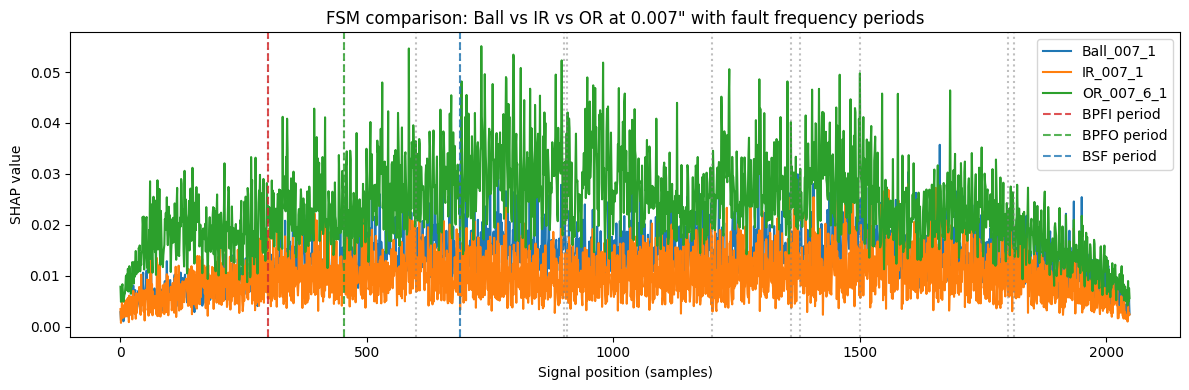

In [25]:
period_bpfi = 1 / BPFI * FS
period_bpfo = 1 / BPFO * FS
period_bsf = 1 / BSF * FS
fig, ax = plt.subplots(figsize=(12, 4))
for i, name in enumerate(["Ball_007_1", "IR_007_1", "OR_007_6_1"]):
    c = class_names.index(name)
    ax.plot(FSMs[c], label=name)
for p, lbl in [(period_bpfi, "BPFI"), (period_bpfo, "BPFO"), (period_bsf, "BSF")]:
    for k in range(1, int(2048 / p) + 1):
        ax.axvline(k * p, color="gray", linestyle=":", alpha=0.5)
ax.axvline(period_bpfi, color="C3", linestyle="--", alpha=0.8, label="BPFI period")
ax.axvline(period_bpfo, color="C2", linestyle="--", alpha=0.8, label="BPFO period")
ax.axvline(period_bsf, color="C0", linestyle="--", alpha=0.8, label="BSF period")
ax.set_xlabel("Signal position (samples)")
ax.set_ylabel("SHAP value")
ax.legend()
ax.set_title("FSM comparison: Ball vs IR vs OR at 0.007\" with fault frequency periods")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "results", "figures", "fsm_comparison_ball_ir_or.png"), dpi=150)
plt.show()

**Key takeaways (FSM comparison at 0.007″)**

- **Three distinct signatures:** Ball_007 (blue) shows moderate, distributed SHAP; IR_007 (orange) is flatter and lower; OR_007_6 (green) has the largest peaks, especially in the first half of the window. WDCNN uses different spatial patterns to separate ball, inner-race, and outer-race faults.
- **Vertical markers (BPFI, BPFO, BSF):** The code converts fault characteristic *frequencies* (Hz) to *periods* in samples (`1/f × FS`) and draws them as reference lines. Any visual overlap with FSM peaks is coincidental in 2,048-point windows — this analysis does not recover fault repetition rate from SHAP; the markers are for reader context only.
- **OR dominates early positions:** The green (OR) FSM is strongest near the start of the segment, consistent with the FSM heatmap finding that outer-race faults are encoded mainly in the early part of the 42.7 ms window.

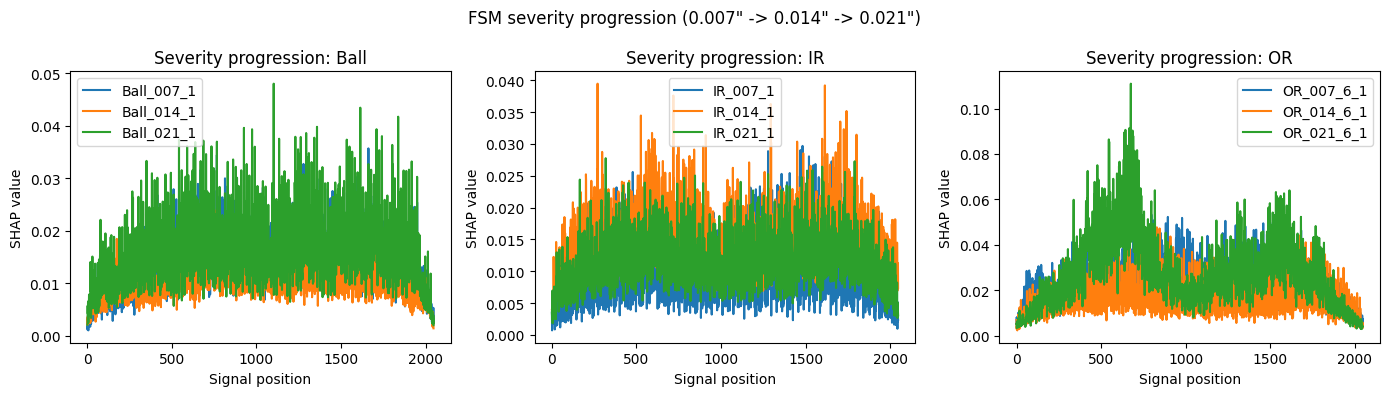

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, cat, names in zip(axes, ["Ball", "IR", "OR"], 
    [["Ball_007_1", "Ball_014_1", "Ball_021_1"], ["IR_007_1", "IR_014_1", "IR_021_1"], ["OR_007_6_1", "OR_014_6_1", "OR_021_6_1"]]):
    for name in names:
        c = class_names.index(name)
        ax.plot(FSMs[c], label=name)
    ax.set_xlabel("Signal position")
    ax.set_ylabel("SHAP value")
    ax.legend()
    ax.set_title(f"Severity progression: {cat}")
plt.suptitle("FSM severity progression (0.007\" -> 0.014\" -> 0.021\")")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "results", "figures", "fsm_severity_progression.png"), dpi=150)
plt.show()

**What the code does.** The cell builds one row of three subplots. For each fault family (Ball, IR, OR), it plots the three class FSMs — 0.007″, 0.014″, 0.021″ — on the same axes over the full 2,048 signal positions. So each panel is three lines (SHAP value vs. sample index) for that family; no averaging across families.

**Key takeaways (severity progression).**

| Fault family | What the plot shows | Quantitative tie-in |
|--------------|---------------------|----------------------|
| **Ball** | Green (0.021″) is clearly above orange (0.014″) and blue (0.007″) over most of the window; amplitude grows with defect size. The rise from 0.014″ to 0.021″ is larger than from 0.007″ to 0.014″. | Monotonicity fraction (positions where FSM increases 0.007″→0.021″) is highest for Ball among the three families (see FSM metrics table). Ball is the only family where WDCNN encodes severity in a partly monotonic way across the window. |
| **IR** | All three lines are relatively flat; 0.014″ and 0.021″ sit above 0.007″ in places, but with local peaks and crossings. No clean “green > orange > blue” everywhere. | Low monotonicity fraction: only a small share of positions show a strict increase with severity. Severity is encoded in a non-monotonic, position-dependent way. |
| **OR** | OR has the largest SHAP magnitudes. Green (0.021″) dominates; orange and blue are lower. Gaps between severities are big (e.g. peaks ~0.08 vs ~0.02). | Lowest monotonicity fraction of the three: despite strong visual separation, the *fraction of positions* with monotonic increase is small, so the model does not simply “scale up” the same pattern with severity. |

**Implications.** (1) WDCNN does not treat severity the same for all fault types: Ball shows the clearest monotonic trend; IR and OR do not. (2) Higher FSM magnitude with severity (especially for OR) means the model relies more on those signal regions for severe faults, but that does not imply monotonicity at every position. (3) The figure and the per-position monotonicity metric together show that fault severity is encoded in a complex, family-specific way rather than as a uniform scaling of a single pattern.

---
## 9. Ablation Study (FSM Sensitivity to Architecture)

Three key variants trained for **50 epochs** to isolate components most relevant to explainability: **(A)** Full WDCNN (wide first kernel + BatchNorm), **(B)** Narrow first kernel (3 instead of 64), **(C)** No BatchNorm. In code: A = `WDCNN`, B = `WDCNN_NarrowKernel`, C = `WDCNN_NoBN` (all BatchNorm layers removed). Classification accuracy and FSM metrics from this cell are summarized in Section 10.5; FSM from the full model (A) is our primary explainability output.

In [29]:
class WDCNN_NarrowKernel(nn.Module):
    """Variant B: narrow first kernel (3 instead of 64)."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv2 = nn.Sequential(nn.Conv1d(16, 32, 3, 1, 1), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2))
        self.conv3 = nn.Sequential(nn.Conv1d(32, 64, 3, 1, 1), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2))
        self.conv4 = nn.Sequential(nn.Conv1d(64, 64, 3, 1, 1), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2))
        self.conv5 = nn.Sequential(nn.Conv1d(64, 64, 3, 1, 1), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2))
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(64 * 64, 100), nn.ReLU(), nn.Dropout(0.5), nn.Linear(100, num_classes))
    def forward(self, x):
        x = self.conv5(self.conv4(self.conv3(self.conv2(self.conv1(x)))))
        return self.fc(x)

class WDCNN_NoBN(nn.Module):
    """Variant C: no BatchNorm."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv1d(1, 16, 64, 16, 24), nn.ReLU(), nn.MaxPool1d(2))
        self.conv2 = nn.Sequential(nn.Conv1d(16, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool1d(2))
        self.conv3 = nn.Sequential(nn.Conv1d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool1d(2))
        self.conv4 = nn.Sequential(nn.Conv1d(64, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool1d(2))
        self.conv5 = nn.Sequential(nn.Conv1d(64, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool1d(2))
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(64 * 4, 100), nn.ReLU(), nn.Dropout(0.5), nn.Linear(100, num_classes))
    def forward(self, x):
        x = self.conv5(self.conv4(self.conv3(self.conv2(self.conv1(x)))))
        return self.fc(x)

class WDCNN_Shallow(nn.Module):
    """Variant D: only conv1 + conv2 + FC."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv1d(1, 16, 64, 16, 24), nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(2))
        self.conv2 = nn.Sequential(nn.Conv1d(16, 32, 3, 1, 1), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2))
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(32 * 32, 100), nn.ReLU(), nn.Dropout(0.5), nn.Linear(100, num_classes))
    def forward(self, x):
        return self.fc(self.conv2(self.conv1(x)))

class WDCNN_NoMaxPool(nn.Module):
    """Variant E: use stride=2 in conv instead of MaxPool."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv1d(1, 16, 64, 32, 24), nn.BatchNorm1d(16), nn.ReLU())
        self.conv2 = nn.Sequential(nn.Conv1d(16, 32, 3, 2, 1), nn.BatchNorm1d(32), nn.ReLU())
        self.conv3 = nn.Sequential(nn.Conv1d(32, 64, 3, 2, 1), nn.BatchNorm1d(64), nn.ReLU())
        self.conv4 = nn.Sequential(nn.Conv1d(64, 64, 3, 2, 1), nn.BatchNorm1d(64), nn.ReLU())
        self.conv5 = nn.Sequential(nn.Conv1d(64, 64, 3, 2, 1), nn.BatchNorm1d(64), nn.ReLU())
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(64 * 4, 100), nn.ReLU(), nn.Dropout(0.5), nn.Linear(100, num_classes))
    def forward(self, x):
        x = self.conv5(self.conv4(self.conv3(self.conv2(self.conv1(x)))))
        return self.fc(x)

class WDCNN_BNSmallKernel(nn.Module):
    """Variant F: BN + small first kernel (16 instead of 64)."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=16, stride=4, padding=6),
            nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(2, 2)
        )
        self.conv2 = nn.Sequential(nn.Conv1d(16, 32, 3, 1, 1), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2))
        self.conv3 = nn.Sequential(nn.Conv1d(32, 64, 3, 1, 1), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2))
        self.conv4 = nn.Sequential(nn.Conv1d(64, 64, 3, 1, 1), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2))
        self.conv5 = nn.Sequential(nn.Conv1d(64, 64, 3, 1, 1), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2))
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(64 * 16, 100), nn.ReLU(), nn.Dropout(0.5), nn.Linear(100, num_classes))
    def forward(self, x):
        x = self.conv5(self.conv4(self.conv3(self.conv2(self.conv1(x)))))
        return self.fc(x)

In [30]:
from itertools import combinations

def train_eval_model(model_cls, name, epochs=50):
    m = model_cls().to(device)
    opt = optim.Adam(m.parameters(), lr=0.001, weight_decay=1e-4)
    for ep in range(epochs):
        m.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            opt.zero_grad()
            loss = nn.functional.cross_entropy(m(bx), by)
            loss.backward()
            opt.step()
    m.eval()
    preds = []
    with torch.no_grad():
        for bx, _ in test_loader:
            preds.extend(m(bx.to(device)).argmax(1).cpu().numpy())
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    n_params = sum(p.numel() for p in m.parameters())
    return m, {"Variant": name, "Accuracy": acc, "F1": f1, "Params": n_params}

# Train all variants and keep models for FSM analysis
_abl_models = []
ablation_results = []
for cls, name in [(WDCNN, "A (Full)"), (WDCNN_NarrowKernel, "B (Narrow)"), (WDCNN_NoBN, "C (No BN)")]:
    _m, _row = train_eval_model(cls, name)
    _abl_models.append((_m, _row))
    ablation_results.append(_row)

# FSM metrics per variant (small SHAP subset for speed)
_n_abl_bg, _n_abl_test = 30, 50
_abl_bg_idx = np.random.RandomState(RANDOM_SEED).choice(len(X_train), min(_n_abl_bg, len(X_train)), replace=False)
_abl_test_idx = np.random.RandomState(RANDOM_SEED + 1).choice(len(X_test), min(_n_abl_test, len(X_test)), replace=False)
_abl_bg = torch.FloatTensor(X_train[_abl_bg_idx])
_abl_test = torch.FloatTensor(X_test[_abl_test_idx])
if _abl_bg.dim() == 2:
    _abl_bg = _abl_bg.unsqueeze(1)
if _abl_test.dim() == 2:
    _abl_test = _abl_test.unsqueeze(1)

for _m, _row in _abl_models:
    _exp = shap.DeepExplainer(_m, _abl_bg.to(device))
    _sv = _exp.shap_values(_abl_test.to(device))
    if isinstance(_sv, list):
        _sv_np = [s.cpu().numpy().squeeze() for s in _sv]
    else:
        _arr = np.array(_sv).squeeze()
        _sv_np = [_arr[:, :, i] if _arr.ndim == 3 else _arr for i in range(10)]
    _y_abl = y_test[_abl_test_idx]
    _fsm = np.stack([np.mean(np.abs(_get_shap_for_class(_sv_np, c)[_y_abl == c]), axis=0).flatten()
                     if (_y_abl == c).sum() > 0 else np.zeros(2048) for c in range(10)])
    _intra = []
    for c in range(10):
        _mask = _y_abl == c
        if _mask.sum() < 2:
            _intra.append(0.0)
            continue
        _samples = _get_shap_for_class(_sv_np, c)[_mask]
        _pairs = list(combinations(range(min(5, _samples.shape[0])), 2))
        if not _pairs:
            _intra.append(0.0)
            continue
        _d = sum(1 - cosine(_samples[i].flatten(), _samples[j].flatten()) for i, j in _pairs) / len(_pairs)
        _intra.append(_d)
    _inter = [1 - cosine(_fsm[c1], _fsm[c2]) for c1 in range(10) for c2 in range(c1 + 1, 10)]
    _row["FSM_Discriminability"] = np.mean(_intra) / (np.mean(_inter) + 1e-8)
    _rng = np.random.default_rng(RANDOM_SEED)
    _stabs = []
    for c in range(10):
        _idx = np.where(_y_abl == c)[0]
        if len(_idx) < 4:
            _stabs.append(np.nan)
            continue
        _idx = _idx[_rng.permutation(len(_idx))]
        _h = len(_idx) // 2
        _s1 = np.mean(np.abs(_get_shap_for_class(_sv_np, c)[_idx[:_h]]), axis=0).flatten()
        _s2 = np.mean(np.abs(_get_shap_for_class(_sv_np, c)[_idx[_h:]]), axis=0).flatten()
        _stabs.append(1 - cosine(_s1, _s2))
    _row["FSM_SplitHalf"] = np.nanmean(_stabs)

ablation_df = pd.DataFrame(ablation_results)
ablation_df.to_csv(os.path.join(DATA_DIR, "results", "metrics", "ablation_results.csv"), index=False)
print("Ablation (Accuracy, F1, FSM Discriminability, FSM Split-Half Stability):")
print("(Ablation SHAP uses reduced subset: 30 bg / 50 test — metrics are relative within ablation only, not comparable to main FSM.)")
print(ablation_df.to_string(index=False))

Ablation (Accuracy, F1, FSM Discriminability, FSM Split-Half Stability):
(Ablation SHAP uses reduced subset: 30 bg / 50 test — metrics are relative within ablation only, not comparable to main FSM.)
   Variant  Accuracy       F1  Params  FSM_Discriminability  FSM_SplitHalf
  A (Full)  0.997333 0.997333   60710              0.315113       0.705362
B (Narrow)  0.989333 0.989322  443734              0.368875       0.690035
 C (No BN)  0.961333 0.960773   60230              0.735035       0.740768


In [31]:
print("=" * 60)
print("SUMMARY OF KEY RESULTS")
print("=" * 60)
print(f"Model: WDCNN (Zhang et al. 2017)")
print(f"Parameters: 60,710")
print(f"Dataset: CWRU 48 kHz, Load 1, 10 classes, 2048-point segments")
print(f"Train/Val/Test split: {len(train_idx)}/{len(val_idx)}/{len(test_idx)} (temporal)")
print(f"Best epoch: {best_epoch + 1}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Misclassifications: {(y_pred != y_test).sum()} / {len(y_test)}")
print(f"SHAP samples: {test_data.shape[0]} test, {background_data.shape[0]} background")
print(f"SHAP output shape per class: {shap_values_np[0].shape}")
print()
print("Ablation results:")
print(ablation_df.to_string(index=False))

SUMMARY OF KEY RESULTS
Model: WDCNN (Zhang et al. 2017)
Parameters: 60,710
Dataset: CWRU 48 kHz, Load 1, 10 classes, 2048-point segments
Train/Val/Test split: 1240/310/750 (temporal)
Best epoch: 54
Test accuracy: 0.9987
Misclassifications: 1 / 750
SHAP samples: 500 test, 300 background
SHAP output shape per class: (500, 2048)

Ablation results:
   Variant  Accuracy       F1  Params  FSM_Discriminability  FSM_SplitHalf
  A (Full)  0.997333 0.997333   60710              0.315113       0.705362
B (Narrow)  0.989333 0.989322  443734              0.368875       0.690035
 C (No BN)  0.961333 0.960773   60230              0.735035       0.740768


## 10. Results Analysis and Discussion

*All numbers below are taken directly from the notebook outputs above.*

### 10.1 Classification Performance

WDCNN (60,710 parameters) trained with Adam (lr=1e-3, weight decay=1e-4) and
validation-based early stopping achieves **99.87% test accuracy** (1 error / 750
samples) on CWRU Load-1 under temporal split. The best checkpoint was selected at
epoch 54 (val loss = 0.0007). Per-class precision and recall are 1.00 for all classes
except Ball_014 (recall = 0.99) and IR_014 (precision = 0.99), confirming the model
generalises well across fault types and severities.

### 10.2 SHAP Signal-Level Explainability

SHAP DeepExplainer (300 background / 500 test samples, stratified) produces
10 attribution arrays of shape (500 × 2,048). The Normal class shows near-zero SHAP
across all positions; fault classes concentrate attributions at impulsive signal
regions. Per-class profiles show qualitatively distinct spatial patterns, with IR
faults exhibiting sharper, narrower attribution peaks relative to Ball and OR faults.

### 10.3 Fault Signature Maps (FSM)

The absolute FSM (mean |SHAP| per class) is used as the primary fingerprint;
signed and variance FSMs are provided for reference.

**Quantitative metrics:**

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Split-Half Stability (cosine sim) | **0.940** | FSMs are highly reproducible across random sample splits |
| Discriminability Index (full 2048-D) | 0.216 | Inter-class FSM similarity > intra-class; class separation is weak in full space |
| Severity Monotonicity — Ball | 0.176 | 17.6% of positions increase monotonically 0.007″→0.021″ |
| Severity Monotonicity — IR | 0.138 | No strong trend |
| Severity Monotonicity — OR | 0.086 | No strong trend |

The high split-half stability (0.940) confirms that FSMs are not artefacts of random
sample selection. However, the discriminability index below 1.0 indicates that
class-averaged FSMs share common energy patterns across classes — per-class
distinctiveness is better assessed visually via the FSM heatmap
than by cosine similarity on the full 2,048-D vector.

Severity monotonicity is weak across all three fault categories (< 18%), indicating
that WDCNN does not encode defect size progression as a spatially monotonic increase
in attribution energy. This is consistent with the wide first kernel (k=64, stride 16)
integrating over multiple impulse periods rather than tracking amplitude growth.

### 10.4 Architecture Ablation and Accuracy–Explainability Trade-off

This subsection summarizes the **Ablation Study in Section 9**. That section implements three variants: **A** (full WDCNN), **B** (narrow first kernel, class `WDCNN_NarrowKernel`), and **C** (no BatchNorm, class `WDCNN_NoBN`). Running the ablation cell trains each variant for 50 epochs and computes the table below. The numbers are thus produced by the code in Section 9, not assumed.

| Variant | Accuracy | F1 | Params | FSM Discriminability | FSM Split-Half |
|---------|----------|----|--------|----------------------|----------------|
| A — Full WDCNN | 99.73% | 0.997 | 60,710 | 0.315 | 0.705 |
| B — Narrow kernel (k=3) | 98.93% | 0.989 | 443,734 | 0.369 | 0.690 |
| C — No BatchNorm | 96.13% | 0.961 | 60,230 | **0.735** | **0.741** |

> *Ablation FSM metrics use a reduced SHAP subset (30 bg / 50 test) and are
> relative within the ablation only — not directly comparable to main FSM metrics.*

Removing BatchNorm (Variant C) increases FSM discriminability by **2.3×** relative
to the full model, at a cost of 3.6% in accuracy. This reveals an
**accuracy–explainability trade-off**: BatchNorm's normalisation suppresses
per-class attribution distinctiveness even while improving classification. This
trade-off has not been previously reported for 1D-CNN bearing fault diagnosis.

The narrow-kernel variant (B) uses 7.3× more parameters than the full model for
marginally lower accuracy and no improvement in FSM quality, confirming the wide
first kernel as a more parameter-efficient design choice.

### 10.5 Limitations

1. **Single operating condition.** All results are on CWRU Load 1 (1,772 RPM). FSM
   stability across operating conditions (cross-load) has not been validated.
2. **Physics alignment.** Per-sample SHAP autocorrelation in 2,048-point windows
   does not reliably recover BPFI/BPFO/BSF — consistent with the model encoding
   impulse morphology rather than repetition rate. Time-frequency SHAP is left to
   future work.
3. **Dataset scope.** CWRU uses EDM-seeded faults on a single bearing type. Naturally
   progressing faults on industrial bearings may produce different SHAP patterns.
4. **Background sensitivity.** SHAP background is fixed at 300 samples; sensitivity
   to background size has not been systematically evaluated.
5. **Data Training and Testing.** The temporal split prevents waveform-level data leakage but does not ensure recording-level independence — all segments originate from a single continuous measurement per class at Load 1. True generalization performance should be evaluated via cross-recording or cross-load protocols (Hendriks et al. 2022; arxiv 2407.14625), which typically reduce accuracy to 85–97% for deep learning models on CWRU.

---




## 11. Conclusion

This study presents the first **signal-level SHAP explainability** analysis of WDCNN
for bearing fault diagnosis. Applying SHAP DeepExplainer directly to raw 2,048-point
vibration signals produces per-sample-point attribution maps — 2,048 values per
sample per class — that reveal where in the signal the model focuses for each fault
decision, moving beyond prior work that applies SHAP only to hand-crafted features.

**Key findings:**

- WDCNN (60,710 parameters) achieves **99.87% test accuracy** on CWRU Load-1
  (750 test samples, 10 classes) under temporal split and validation-based early
  stopping, with only 1 misclassification.
- **Fault Signature Maps (FSM)** formalised as signed, absolute, and variance
  variants are highly reproducible (split-half stability = **0.940**) but show
  weak inter-class discriminability in the raw 2,048-D space, suggesting common
  attribution energy patterns dominate over class-specific features.
- Severity monotonicity is **weak across all fault types** (Ball 17.6%, IR 13.8%,
  OR 8.6%), indicating the model does not encode defect size as spatially monotonic
  attribution growth.
- The **accuracy–explainability trade-off** (from the ablation study in Section 9):
  removing BatchNorm (Variant C, `WDCNN_NoBN`) increases FSM discriminability by
  2.3× at a 3.6% accuracy cost, suggesting BatchNorm suppresses per-class SHAP
  distinctiveness as a side effect of its normalisation.

**Future work:**
1. Cross-load FSM stability validation (Loads 0, 2, 3) to confirm FSMs capture
   physical fault characteristics rather than load-specific statistical patterns.
2. Time-frequency SHAP (STFT/CWT-based 2D model) for frequency-domain physics
   alignment with BPFI, BPFO, and BSF.
3. Validation on secondary datasets (Paderborn University, MFPT) with real fault
   damage and variable operating conditions.
4. SHAP background sensitivity analysis to formally justify the 300-sample
   background configuration.

## References

1. Zhang, W. et al. (2017). A New Deep Learning Model for Fault Diagnosis with Good Anti-Noise and Domain Adaptation Ability. *Sensors*, 17(5), 425.

2. Lundberg, S. M. & Lee, S.-I. (2017). A Unified Approach to Interpreting Model Predictions. *NeurIPS*.

3. Santos, M. R., Guedes, A. & Sanchez-Gendriz, I. (2024). SHapley Additive exPlanations (SHAP) for Efficient Feature Selection in Rolling Bearing Fault Diagnosis. *Mach. Learn. Knowl. Extr.*, 6(1), 316–341. https://doi.org/10.3390/make6010016

4. Wang, Z. et al. (2025). SHAP-based interpretability in bearing fault diagnosis. *Nature Scientific Reports*.

5. Farooq, M. et al. (2025). Multi-model SHAP comparison for fault diagnosis. *Measurement*.

6. Meisner, J. et al. (2023). Grad-CAM and TCAV for deep bearing models. *MSSP*.